## For Google Colab

In [ ]:
# For google colab
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/Othercomputers/My Mac/src/')
colab=True
!pip install mnist1d

Mounted at /content/drive


## Configuration

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
from pathlib import Path
from tqdm import tqdm
import json
import sys
import os
import pickle
import pandas as pd
if 'colab' not in locals():
  sys.path.insert(0, "../src/")
from Network import *
from plotting import *
from utilsMNIST import *
from utils import *
from mnist1d.data import make_dataset, get_dataset_args, get_templates
from mnist1d.utils import from_pickle, to_pickle, ObjectView, set_seed, plot_signals

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)
model_config = dict(default_model_config)
dt = general_config["dt"]
data_config["final_seq_length"] = int(data_config["duration"]/dt)

seed = 0
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

n_steps = data_config["final_seq_length"]
answer_steps = int(model_config["answer_period"]/dt)
pad_steps = int(data_config["prepad"]/dt)

error_window = 20
error_steps = -1#6 #number of error_window
max_error_start = n_steps - error_window -1 
min_error_start = n_steps - answer_steps

Skip = False
small_model = False
GLE_like = False

general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

save_path = "../Figures/MNIST1DRecord.pkl"

beta = torch.zeros(n_steps).to(device)
beta[-answer_steps:]=1.
beta /= beta.sum()

if small_model: #small model (14k) for notebook demonstration
    train_config["num_epochs"] = 100
    model_config["LP_size"] = [36, 54, 60, 60] # acc 92
    model_config["Ins_size"] = [72]


if Skip: #small skip connection for notebook demonstration
    model_config["LP_size"] = [60, 60, 60, 60, 72]
    model_config["Ins_size"] = [72]
    model_config["num_LP_layers"] = 5
    model_config["num_Ins_layers"] = 1
    model_config['Tau3'] = [1, 8.0]
    model_config['Tau4'] = [2.5, 6.6]
    model_config['skip_connection'] = "One"

#######################
if error_steps != -1:
    model_config['skip_connection'] = "All"
    answer_steps = 180
    model_config['Tau4'] = [80, 120]
    model_config['rho_scale'] = 0.25

if GLE_like: #GLE Compare
    model_config["LP_size"] = [54, 54, 54, 54, 54, 54]
    model_config["num_LP_layers"] = 6
    model_config["num_Ins_layers"] = 0
    model_config['Tau1'] = [1.2, 3.2, 6.2]
    model_config['Tau2'] = [1.1, 3.1, 6.1]
    model_config['Tau3'] = [1.3, 3., 6.]
    model_config['Tau4'] = [1.4, 2.9, 5.9]
    model_config['Tau5'] = [1., 2.8, 5.8]
    model_config['rho_scale'] = 0.5

cpu


## Prepare MNIST-1D

Templates for the MNIST-1D dataset:


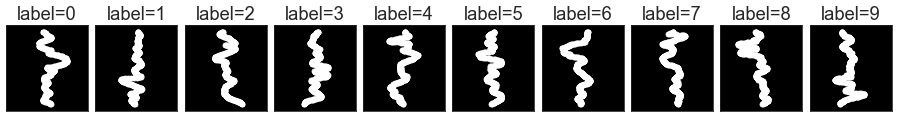

In [3]:
data = make_dataset(ObjectView(data_config))
templates = get_templates()
print("Templates for the MNIST-1D dataset:")
x = templates['x']
t = templates['t']
y = templates['y']
fig = plot_signals(x, t, labels=y, args=ObjectView(data_config),
                   ratio=1.33, dark_mode=True, do_transform=True)

In [4]:
print(data.keys())
x, y = torch.tensor(data['x'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y'], dtype=torch.int64)
x_test, y_test = torch.tensor(data['x_test'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y_test'], dtype=torch.int64)
x.shape, y.shape

dict_keys(['x', 'x_test', 'y', 'y_test', 't', 'templates'])


(torch.Size([4000, 360, 1]), torch.Size([4000]))

In [5]:
for i in range(10):
    print(np.argwhere(y[:100]==i))

tensor([[ 7, 18, 32, 40, 64, 73, 84, 87, 91]])
tensor([[ 9, 16, 36, 44, 55, 71, 79]])
tensor([[ 0, 21, 45, 46, 56, 61, 67, 97]])
tensor([[ 8, 13, 19, 23, 25, 31, 38, 48, 65, 74, 76, 93]])
tensor([[ 2, 12, 14, 20, 24, 26, 30, 34, 39, 58, 60, 77, 82, 83, 90]])
tensor([[ 3, 15, 62, 72, 85, 88]])
tensor([[ 1,  4,  5,  6, 10, 22, 35, 37, 50, 57, 68, 80, 86, 92, 98]])
tensor([[28, 41, 49, 53, 66, 75, 81, 94, 99]])
tensor([[27, 29, 33, 42, 59, 69, 70, 95, 96]])
tensor([[11, 17, 43, 47, 51, 52, 54, 63, 78, 89]])


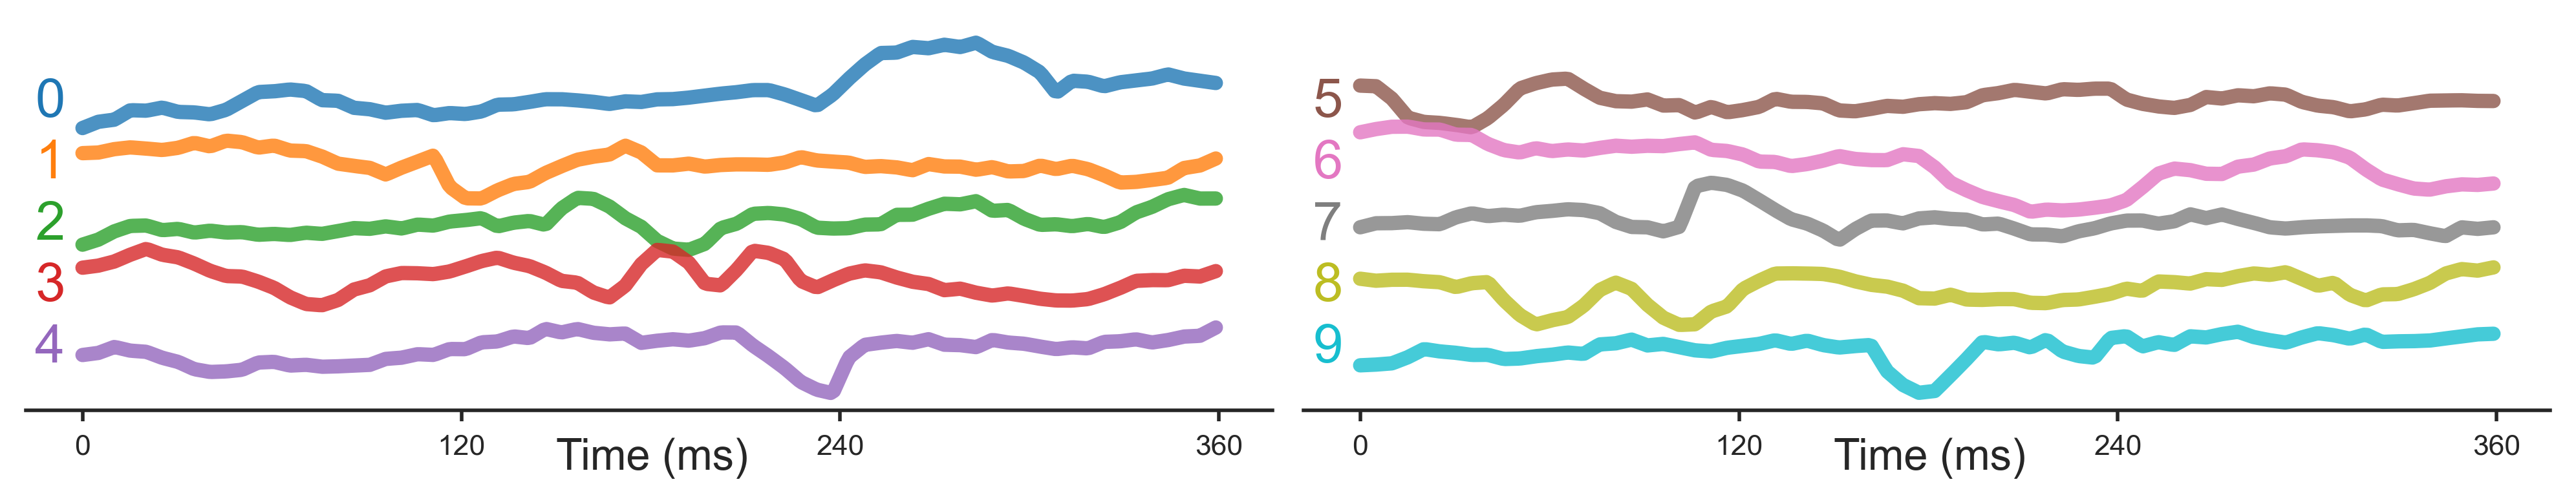

In [86]:
fig, axs = plt.subplots(1, 2, figsize = (10, 2), dpi=400, sharey=True)
colors=[
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
    '#bcbd22', '#17becf'
]
idx = [32, 71, 21, 23, 82, 62, 1, 53, 42, 78]
for i in range(5):
    number = i
    axs[0].plot(x[idx[number]]-4*i, label = number, linewidth = 4,
                color=colors[number], alpha = 0.8)
    axs[0].annotate(number, xy=(-15, -4*i-1.), fontsize = 15, color=colors[number])
for i in range(5):
    number = i+5
    axs[1].plot(x[idx[number]]-4*i, label = number, linewidth = 4,
                color=colors[number], alpha = 0.8)
    axs[1].annotate(number, xy=(-15, -4*i-1.), fontsize = 15, color=colors[number])

axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['left'].set_visible(False)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['left'].set_visible(False)
axs[0].set_yticks([])
axs[0].set_xticks([0, 120, 240, 360], [0, 120, 240, 360])
axs[1].set_xticks([0, 120, 240, 360], [0, 120, 240, 360])

#axs[0].set_xlabel("Time (ms)")
axs[0].annotate("Time (ms)", xy=(150, -24), xycoords='data', annotation_clip=False, fontsize=12)
axs[1].annotate("Time (ms)", xy=(150, -24), xycoords='data', annotation_clip=False, fontsize=12)

plt.tight_layout()
plt.savefig('../Figures/MNISTAnim.png')
plt.show()

## Train KP

In [5]:
Method = 'KP'
# init network and optimizer
train_config["update_times"] = 3
if Method=='BPTT':
    model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)
    train_fn = train_batch_BPTT
    factor = 0.75
    adam_beta = (0.9, 0.999)
else:
    if train_config["update_times"]>1:
        update_timing = n_steps-np.linspace(0, n_steps, num=train_config["update_times"], endpoint=False, dtype=np.int16)-1
        train_fn = train_batch_periodic(update_timing = update_timing)
    else:
        train_fn = train_batch_delay
    factor = 0.75
    adam_beta = (0.8, 0.995)
    if Method=='KP':
        model = buildKPNet(model_config, general_config).to(device)
    elif Method in ['GLE','RF/E','LE']:
        model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)
    else:
        raise NotImplementedError

model = torch.compile(model)

if GLE_like:
    model.layers[0].tau = model.layers[3].tau 
    model.layers[0].dt_tau = model.layers[3].dt_tau
    model.layers[0].decay = model.layers[3].decay
    model.layers[0].tau_dt = model.layers[3].tau_dt
    if Method == 'KP':
        model.layers[0].tau_unique = model.layers[3].tau_unique
        model.layers[0].dt_tau_uniq = model.layers[3].dt_tau_uniq
        model.layers[0].decay_uniq = model.layers[3].decay_uniq
        model.layers[0].repeat_tau = model.layers[3].repeat_tau
        model.layers[0].n_tau = model.layers[3].n_tau
    adam_beta = (0.9, 0.999)
    factor = 0.75
    train_config["learning_rate"] = 1e-2

if Method=="GLE":
    for l in model.layers[:4]:
        #l.tau_dt = torch.clamp(l.tau_dt, 0, 5)
        l.tau_dt /= 3

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=adam_beta,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=factor,
    patience=2
)

kernel_record_pre = extract_kernel(
    model,
    n_steps=int(1.5*data_config["final_seq_length"]),
    layer_idx=model_config["num_LP_layers"]
)

best_test_acc = 0.

rho bar
A skip connection activated


In [6]:
print("Training started...")
acc_record, loss_record = [], []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        if error_steps==-1:
            beta_random = beta
        else:
            beta_random = torch.zeros(n_steps).to(device)
            select_steps = np.random.choice(max_error_start-min_error_start, error_steps, replace=False) + min_error_start
            for error_start in select_steps:
                beta_random[error_start: error_start+error_window] = 1.
            beta_random /= beta_random.sum()
        total_error = train_fn(model, optimizer, x[idx].to(device),
                                        y[idx].to(device), answer_steps, pad_steps, beta_random)
        Cum_errors += total_error
    Cum_errors /= permu.shape[0]

    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                            answer_steps, pad_steps, beta)
    scheduler.step(test_loss)
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

print('finished')

Training started...


 42%|███████████████████████████████████▎                                               | 17/40 [00:42<00:57,  2.49s/it]


KeyboardInterrupt: 

### Save record to pickle

In [13]:
save_dict = {'acc':np.array(acc_record), 'loss':np.array(loss_record), 'seed':seed, 'error_signal':(error_window, error_steps)}
with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)
group = 'Small' if small_model else 'Large'
if Skip:
    group = 'Skip'
#All_record[group][Method].append(save_dict)
All_record["Error_Occ"] = {}
All_record["Error_Occ"][group]=[save_dict]

with open(save_path, 'wb') as handle:
    pickle.dump(All_record, handle, protocol=pickle.HIGHEST_PROTOCOL)

All_record

{'Small': {'n_param': 14080,
  'KP': [{'acc': array([35.8, 34.6, 20.1, 41.8, 60.3, 44. , 50. , 59.9, 57.2, 50.8, 58.3,
           60.8, 59.8, 58. , 61.1, 61.5, 76.8, 71. , 56.4, 66.4, 74.1, 75.2,
           68.6, 81.3, 79.6, 80.7, 76.8, 83.9, 85.2, 71. , 67.3, 87. , 77.6,
           77.8, 81.2, 85. , 83.8, 86. , 88.5, 85.5, 86.5, 86.7, 79.1, 83.9,
           83.2, 84.5, 89.6, 88.4, 86. , 86.1, 88.2, 89.2, 87.2, 90.6, 90.1,
           90.3, 86.1, 89.2, 92.1, 90.9, 89.8, 91.1, 91.4, 88.7, 92.6, 92.8,
           87.3, 91.3, 92.2, 93.1, 92.3, 92.8, 91.2, 91.1, 93.9, 93.5, 92.4,
           92.5, 92.6, 93.3, 92.2, 93.4, 92.6, 90.7, 93.6, 92.6, 94.7, 93.1,
           94.7, 93.1, 94.5, 93.8, 93.9, 93.3, 93.2, 94. , 93. , 94.2, 94.8,
           94.5, 93.9, 93.7, 94.1, 94.1, 94.1, 93.3, 94.5, 95.6, 95.1, 94.1,
           94.6]),
    'loss': array([0.2146, 0.2113, 0.2104, 0.2047, 0.2011, 0.1985, 0.1966, 0.1934,
           0.1935, 0.1946, 0.1901, 0.1876, 0.1872, 0.1879, 0.1831, 0.1871,
           

## Plot Learning Curve

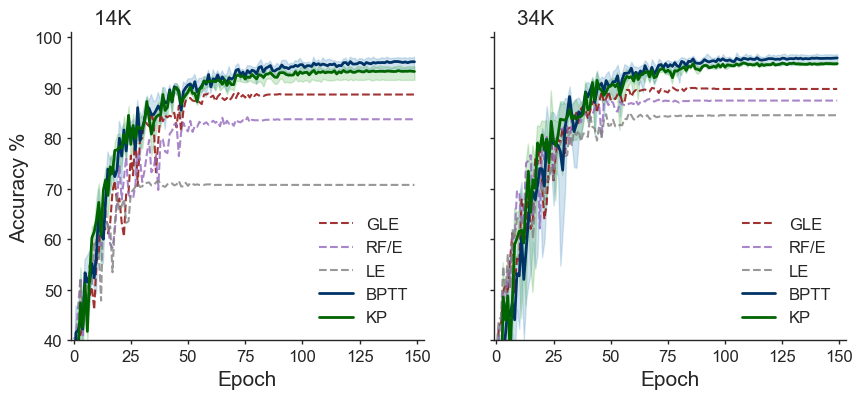

In [3]:
plot_config = {'Large': {'KP':[darkgreen, 'KP'],
                         'BPTT': [darkblue, 'BPTT'],
                         'GLE': [darkred, 'GLE'],
                         'RF/E': [purple, 'RF/E'],
                         'LE': [gray, 'LE'],
                         },
               'Small': {'KP': [green, 'KP'],
                         'BPTT': [blue, 'BPTT'],
                         'GLE': [darkred, 'GLE'],
                         'RF/E': [purple, 'RF/E'],
                         'LE': [gray, 'LE'],
                         },
               'Skip': {'KP': [darkgreen, 'KP'],
                        'BPTT': [darkblue, 'BPTT'],
                       }
               }

with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)

df = pd.read_csv("../Figures/MNIST1D_KP_BPTT.csv", index_col='Step')
epochs = np.arange(150)
### Large and Small model ###
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for i, group in enumerate(['Small', 'Large']):
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].tick_params(axis='both', which='major', labelsize=12)
    
    for method in All_record[group].keys():
        record = All_record[group][method]
        if method in ['n_param', 'KP', 'BPTT'] or len(record)==0:
            continue
        color, label = plot_config[group][method]
        for re in record:
            if len(re['acc'])<150:
                re['acc'] = np.pad(re['acc'], (0, 150-len(re['acc'])), mode = 'edge')
                re['loss'] = np.pad(re['loss'], (0, 150-len(re['loss'])), mode = 'edge')
            axs[i].plot(re['acc'], label=label, color=color, linewidth=1.5, alpha=0.8, linestyle='--')

axs[0].plot(df["Group: small_BPTT - test_acc"], label="BPTT", color=darkblue, linewidth=2)
axs[0].fill_between(epochs, df["Group: small_BPTT - test_acc__MIN"], df["Group: small_BPTT - test_acc__MAX"], alpha=0.2, color=blue)
axs[1].plot(df["Group: Large_BPTT - test_acc"], label="BPTT", color=darkblue, linewidth=2)
axs[1].fill_between(epochs, df["Group: Large_BPTT - test_acc__MIN"], df["Group: Large_BPTT - test_acc__MAX"], alpha=0.2, color=blue)

axs[0].plot(df["Group: Small - test_acc"], label="KP", color=darkgreen, linewidth=2)
axs[0].fill_between(epochs, df["Group: Small - test_acc__MIN"], df["Group: Small - test_acc__MAX"], alpha=0.2, color=green)
axs[1].plot(df["Group: Large - test_acc"], label="KP", color=darkgreen, linewidth=2)
axs[1].fill_between(epochs, df["Group: Large - test_acc__MIN"], df["Group: Large - test_acc__MAX"], alpha=0.2, color=green)

axs[0].set_ylim(40, 101)
axs[0].set_xlim(-1, 153)
axs[1].set_xlim(-1, 153)
axs[0].set_xlabel('Epoch', fontsize = 15)
axs[1].set_xlabel('Epoch', fontsize = 15)
axs[0].set_ylabel('Accuracy %', fontsize = 15)
#axs[1].set_ylabel('Accuracy %', fontsize = 15)
axs[0].set_title('    14K', loc='left', fontsize = 15)
axs[1].set_title('    34K', loc='left', fontsize = 15)

axs[0].legend(loc='lower right', fontsize = 12)
axs[1].legend(loc='lower right', fontsize = 12)

plt.savefig('../Figures/MNIST1D_S-L.png')
plt.show()

In [4]:
df2 = pd.read_csv("../Figures/MNIST1D_SKIP.csv")
result = {}

# extract sorted seeds
seeds = np.sort(df2['general_config.seed'].unique())
result['seed'] = seeds

methods = ['BPTT', 'KP']
ins_sizes = ['[72]', '[120]']

for method in methods:
    for ins in ins_sizes:
        for skip in [True, False]:
            if (ins=='[120]' and skip):
                continue
            sub = df2[
                (df2['train_config.method'] == method) &
                (df2['model_config.Ins_size'] == ins) &
                (df2['model_config.skip_connection'] == skip)
            ]
            
            # align order with seeds
            sub = sub.set_index('general_config.seed').loc[seeds]
            
            key = f"{method}_{'skip' if skip else 'noskip'}_{ins}"

            result[key] = (
                sub['Best Test Acc']
                .reindex(seeds)      # safe alignment
                .to_numpy()
            )

print(result)

{'seed': array([   0,   42,  428,  781, 3407]), 'BPTT_skip_[72]': array([96.8, 95.9, 96. , 96.3, 95.2]), 'BPTT_noskip_[72]': array([94.2, 95.5, 96.1, 95.6, 96.1]), 'BPTT_noskip_[120]': array([95.6, 96.8, 95.1, 96.2, 97. ]), 'KP_skip_[72]': array([95.8, 95.9, 96.1, 96. , 95.5]), 'KP_noskip_[72]': array([91.9, 94.5, 93.7, 93.9, 94.6]), 'KP_noskip_[120]': array([95. , 95. , 95.3, 95.1, 95.3])}


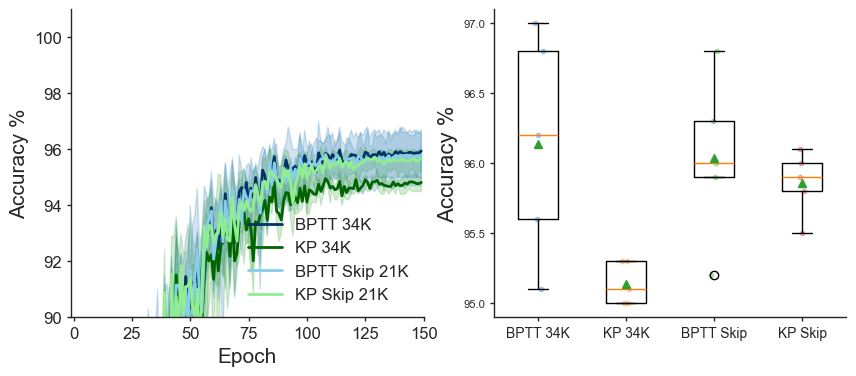

In [16]:
### Large and Skip model ###
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

####ax0#####
axs[0].plot(df["Group: Large_BPTT - test_acc"], label="BPTT 34K", color=darkblue, linewidth=2)
axs[0].fill_between(epochs, df["Group: Large_BPTT - test_acc__MIN"], df["Group: Large_BPTT - test_acc__MAX"],
                    alpha=0.2, color=blue)
axs[0].plot(df["Group: Large - test_acc"], label="KP 34K", color=darkgreen, linewidth=2)
axs[0].fill_between(epochs, df["Group: Large - test_acc__MIN"], df["Group: Large - test_acc__MAX"],
                    alpha=0.2, color=green)

axs[0].plot(df["Group: skip_BPTT - test_acc"], label="BPTT Skip 21K", color=lightblue, linewidth=2)
axs[0].fill_between(epochs, df["Group: skip_BPTT - test_acc__MIN"], df["Group: skip_BPTT - test_acc__MAX"],
                    alpha=0.2, color=blue)
axs[0].plot(df["Group: skip - test_acc"], label="KP Skip 21K", color=lightgreen, linewidth=2)
axs[0].fill_between(epochs, df["Group: skip - test_acc__MIN"], df["Group: skip - test_acc__MAX"],
                    alpha=0.2, color=green)
axs[0].set_ylim(90, 101)
axs[0].set_xlim(-1, 150)
axs[0].set_xlabel('Epoch', fontsize = 15)
axs[0].set_ylabel('Accuracy %', fontsize = 15)
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].tick_params(axis='both', which='major', labelsize=12)
axs[0].legend(loc='lower right', fontsize = 12)

####ax1#####
data = [result['BPTT_noskip_[120]'], result['KP_noskip_[120]'], result['BPTT_skip_[72]'], result['KP_skip_[72]']]
#axs[1].violinplot(data, positions=[0,1,2,3], showmeans=True)
axs[1].boxplot(data, positions=[0,1,2,3], showmeans=True)
axs[1].set_xticks([0,1,2,3], ['BPTT 34K', 'KP 34K', 'BPTT Skip', 'KP Skip'], fontsize=10)
axs[1].set_ylabel("Accuracy %", fontsize=16)
axs[1].set_yticks([95, 95.5, 96, 96.5, 97])
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

for i, d in enumerate(data):
    x = np.random.normal(i, 0.03, size=len(d))  # small horizontal jitter
    axs[1].scatter(x, d, alpha=0.3, s=10)

plt.savefig('../Figures/MNIST1D_Skip.png')
plt.show()

In [ ]:
for l in model.layers[:2]:
    print(l.TauDE, l.decay_de)
    print(l.elig.shape, torch.abs(l.elig).mean())
    print(torch.abs(l.W_in).mean(), torch.abs(l.bias).mean())
    print()

In [ ]:
#TEST
acc, loss = test(model, x_test.to(device), y_test.to(device), 1.4*answer_period)
print('Test Accuracy: ', acc, "Test Loss", loss)

In [ ]:
kernel_record_post = extract_kernel(
    model,
    n_steps=int(1.5*data_config["final_seq_length"]),
    layer_idx=model_config["num_LP_layers"]
)

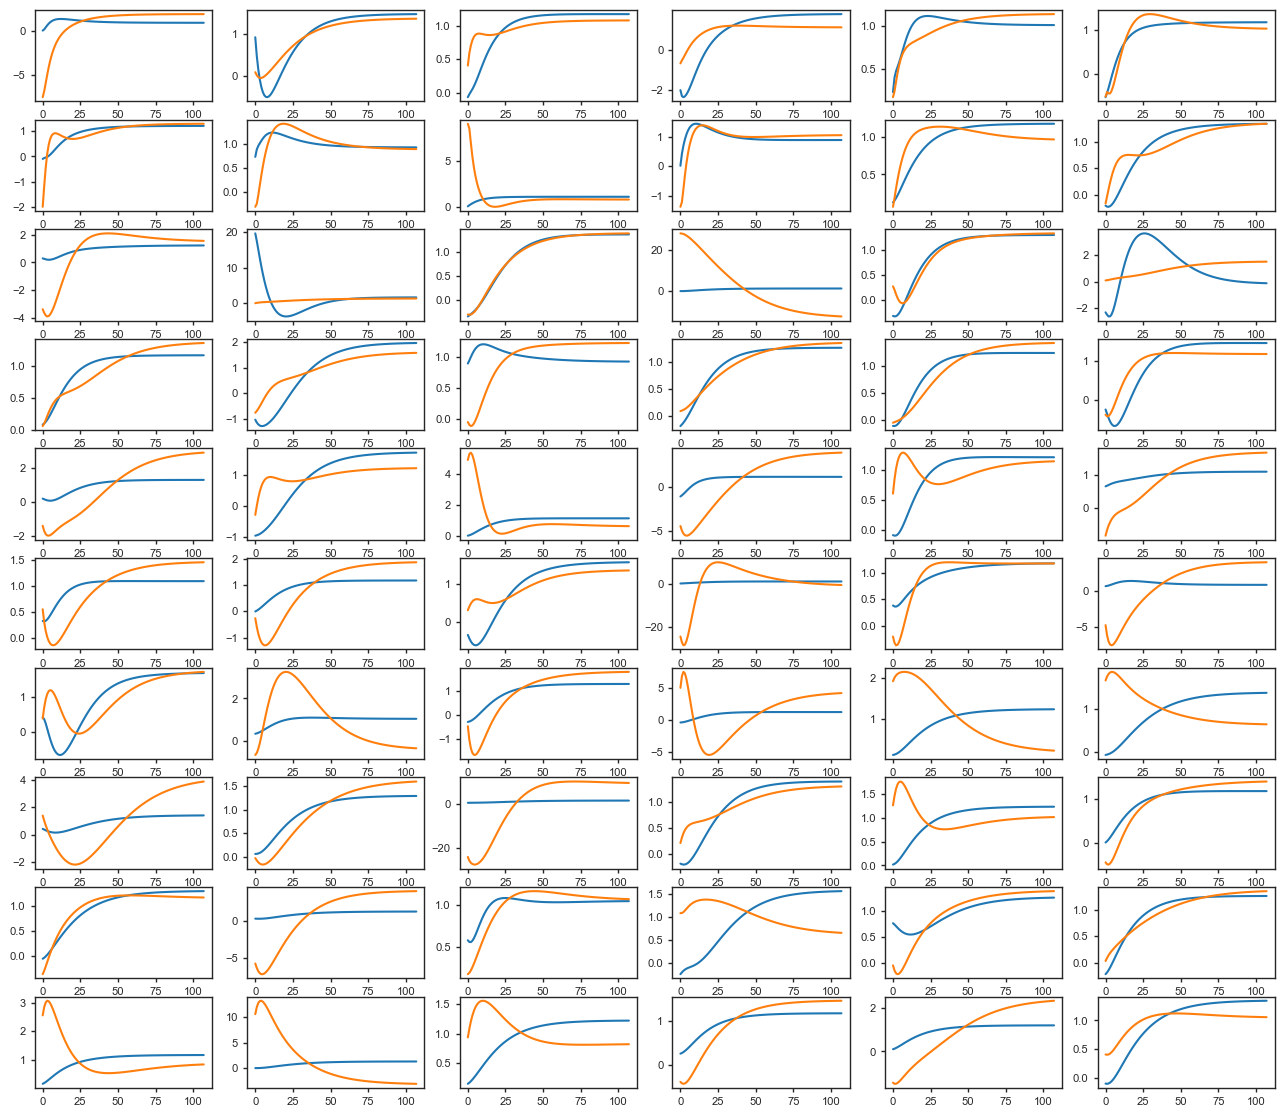

In [ ]:
kernel_record_pre_norm = kernel_record_pre / kernel_record_pre.mean(axis=1)[:, None]
kernel_record_post_norm = kernel_record_post / kernel_record_post.mean(axis=1)[:, None]
fig, axs = plt.subplots(10, 6, figsize=(16, 14))
for i, ax in enumerate(axs.ravel()):
    ax.plot(kernel_record_pre_norm[i])
    ax.plot(kernel_record_post_norm[i])

## Evaluation

In [11]:
Saved_model = Path("..") / "saved_models" / "MNIST428_0.5"
with open(Saved_model / "general_config.json") as f:
    general_config = json.load(f)
with open(Saved_model / "model_config.json") as f:
    model_config = json.load(f)
with open(Saved_model / "data_config.json") as f:
    data_config = json.load(f)

general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
data = make_dataset(ObjectView(data_config))
x, y = torch.tensor(data['x'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y'], dtype=torch.int64)
x_test, y_test = torch.tensor(data['x_test'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y_test'], dtype=torch.int64)

dt = general_config["dt"]
data_config["final_seq_length"] = int(data_config["duration"]/dt)

n_steps = data_config["final_seq_length"]
answer_steps = int(model_config["answer_period"]/dt)

model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)
state_dict = torch.load(Saved_model / "best_model_state.pt", map_location=device)
for key in state_dict:
    print(key)
print(model.load_state_dict(state_dict))
print(model_config)

rho bar
_orig_mod.layers.0.W_in
_orig_mod.layers.0.bias
_orig_mod.layers.0.tau
_orig_mod.layers.0.dt_tau
_orig_mod.layers.0.decay
_orig_mod.layers.1.W_in
_orig_mod.layers.1.bias
_orig_mod.layers.1.tau
_orig_mod.layers.1.dt_tau
_orig_mod.layers.1.decay
_orig_mod.layers.2.W_in
_orig_mod.layers.2.bias
_orig_mod.layers.2.tau
_orig_mod.layers.2.dt_tau
_orig_mod.layers.2.decay
_orig_mod.layers.3.W_in
_orig_mod.layers.3.bias
_orig_mod.layers.3.tau
_orig_mod.layers.3.dt_tau
_orig_mod.layers.3.decay
_orig_mod.layers.4.W_in
_orig_mod.layers.4.bias
_orig_mod.layers.4.tau
_orig_mod.layers.4.dt_tau
_orig_mod.layers.4.decay
_orig_mod.layers.5.W_in
_orig_mod.layers.5.bias
_orig_mod.layers.5.tau
_orig_mod.layers.5.dt_tau
_orig_mod.layers.5.decay
_orig_mod.layers.6.W_in
_orig_mod.layers.6.bias
_orig_mod.layers.6.tau
_orig_mod.layers.6.dt_tau
_orig_mod.layers.6.decay


RuntimeError: Error(s) in loading state_dict for OptimizedModule:
	Missing key(s) in state_dict: "_orig_mod.layers.0.decay_rho", "_orig_mod.layers.0.dt_tau_rho", "_orig_mod.layers.0.downstream_mask", "_orig_mod.layers.0.tau_unique", "_orig_mod.layers.0.dt_tau_uniq", "_orig_mod.layers.0.decay_uniq", "_orig_mod.layers.0.repeat_tau", "_orig_mod.layers.0.P", "_orig_mod.layers.0.TauDE", "_orig_mod.layers.0.dt_tau_de", "_orig_mod.layers.0.decay_de", "_orig_mod.layers.1.decay_rho", "_orig_mod.layers.1.dt_tau_rho", "_orig_mod.layers.1.downstream_mask", "_orig_mod.layers.1.tau_unique", "_orig_mod.layers.1.dt_tau_uniq", "_orig_mod.layers.1.decay_uniq", "_orig_mod.layers.1.repeat_tau", "_orig_mod.layers.1.P", "_orig_mod.layers.1.TauDE", "_orig_mod.layers.1.dt_tau_de", "_orig_mod.layers.1.decay_de", "_orig_mod.layers.2.decay_rho", "_orig_mod.layers.2.dt_tau_rho", "_orig_mod.layers.2.downstream_mask", "_orig_mod.layers.2.tau_unique", "_orig_mod.layers.2.dt_tau_uniq", "_orig_mod.layers.2.decay_uniq"

In [23]:
for model_path in ["0_0.5", "0_1", "428_0.5", "428_1", "42_0.5", "42_1"]:
    print(model_path)
    Saved_model = Path("..") / "saved_models" / ("MNIST" + model_path)
    state_dict = torch.load(Saved_model / "best_model_state.pt", map_location=device)
    for l in range(6):
        weights = state_dict["_orig_mod.layers.%d.W_in"%l]
        print(torch.abs(weights).mean())

0_0.5
tensor(1.1318)
tensor(0.3334)
tensor(0.3980)
tensor(0.3908)
tensor(0.3775)
tensor(0.3348)
0_1
tensor(1.1542)
tensor(0.2801)
tensor(0.2941)
tensor(0.2913)
tensor(0.2894)
tensor(0.2722)
428_0.5
tensor(1.0944)
tensor(0.3288)
tensor(0.3860)
tensor(0.3787)
tensor(0.3749)
tensor(0.3363)
428_1
tensor(1.2442)
tensor(0.2752)
tensor(0.2847)
tensor(0.2816)
tensor(0.2811)
tensor(0.2675)
42_0.5
tensor(1.2485)
tensor(0.3296)
tensor(0.3855)
tensor(0.3793)
tensor(0.3840)
tensor(0.3377)
42_1
tensor(1.3676)
tensor(0.2648)
tensor(0.2937)
tensor(0.2811)
tensor(0.2820)
tensor(0.2714)


In [16]:
W = state_dict['layers.0.W_in'].squeeze()
for i in np.arange(10):
    print(torch.sort(W[i*6: i*6+6])[0])

tensor([-2.7663, -0.1169, -0.0715,  0.1248,  1.6720,  2.1343], device='cuda:0')
tensor([-3.3173, -1.3924, -0.2785, -0.1088,  1.1048,  1.1537], device='cuda:0')
tensor([-0.1274,  0.1104,  0.3072,  0.7757,  1.2825,  1.5832], device='cuda:0')
tensor([-2.4090, -1.0736, -0.6458, -0.1624,  0.0671,  0.1192], device='cuda:0')
tensor([-2.8517, -0.0927, -0.0382,  0.1000,  0.3959,  0.6966], device='cuda:0')
tensor([-0.1148, -0.0709,  0.0029,  0.0328,  0.0652,  0.1225], device='cuda:0')
tensor([-0.2970, -0.0466, -0.0405,  0.0026,  0.1004,  0.3007], device='cuda:0')
tensor([-6.6565e-02,  5.3552e-04,  4.4162e-02,  6.6170e-02,  7.7958e-01,
         1.2237e+00], device='cuda:0')
tensor([-2.3673, -1.8933, -0.2230, -0.0837, -0.0367,  1.5093], device='cuda:0')
tensor([-0.3171, -0.2684, -0.2162,  0.3044,  0.3156,  1.9944], device='cuda:0')


In [31]:
state_dict['layers.0.tau']

tensor([ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.2915,  1.2915,
         1.2915,  1.2915,  1.2915,  1.2915,  1.6681,  1.6681,  1.6681,  1.6681,
         1.6681,  1.6681,  2.1544,  2.1544,  2.1544,  2.1544,  2.1544,  2.1544,
         2.7826,  2.7826,  2.7826,  2.7826,  2.7826,  2.7826,  3.5938,  3.5938,
         3.5938,  3.5938,  3.5938,  3.5938,  4.6416,  4.6416,  4.6416,  4.6416,
         4.6416,  4.6416,  5.9948,  5.9948,  5.9948,  5.9948,  5.9948,  5.9948,
         7.7426,  7.7426,  7.7426,  7.7426,  7.7426,  7.7426, 10.0000, 10.0000,
        10.0000, 10.0000, 10.0000, 10.0000], device='cuda:0')

In [7]:
general_config

{'device': 'cpu',
 'dt': 1.0,
 'seed': 89,
 'short_training_run': False,
 'visual_kernel': False}

In [8]:
test_acc, test_acc_r, test_acc_m = test_mul(model, x_test.to(device), y_test.to(device), answer_steps, pad_steps, beta)

In [9]:
print(test_acc, test_acc_r, test_acc_m)

95.6 94.9 81.1


## Gradient similarity

### With layers

In [6]:
model_config["LP_size"] = [60, 60, 60, 60, 60, 60, 60]
model_config["num_LP_layers"] = 7
model_config["num_Ins_layers"] = 0
model_config['Tau1'] = [2.2, 3.2, 5.2]
model_config['Tau2'] = [2.1, 3.1, 5.1]
model_config['Tau3'] = [2., 3., 5.]
model_config['Tau4'] = [1.9, 2.9, 4.9]
model_config['Tau5'] = [1.8, 2.8, 4.8]
model_config['Tau6'] = [1.7, 2.7, 4.7]
model_config["version"] = 0

nLP = model_config['num_LP_layers']
CosSim = torch.nn.CosineSimilarity(dim=-1, eps=1e-6)
num_repeat = 20
Rho_scales = [0.2, 0.6, 1.]
CosSimW, CosSimW2 = [], []

for rho_scale in Rho_scales:
    model_config["rho_scale"] = rho_scale
    CosSimW_record = [[] for _ in range(nLP)]
    CosSimW2_record = [[] for _ in range(nLP)]
    for _ in range(num_repeat):
        model = buildKPNet(model_config, general_config)
        ##### assigned tau to LP rho'###
        # tau = 14
        for l in model.layers[:nLP]:
            l.dt_tau_rho = l.dt_tau#1 / tau
            l.decay_rho = 1 - l.dt_tau_rho
        #     tau -= 2
        ##################################
        idx = (np.random.permutation(4000).reshape(-1, train_config["batch_size"]))[0]
        sample_batch_x = x[idx]
        one_hot_label = one_hot_label = F.one_hot(y[idx], num_classes=10)
        model.reset()
        GradW_all_time = [[] for _ in range(nLP)]
        GradW2_all_time = [[] for _ in range(nLP)]
        total_loss = 0.
        for t in range(n_steps):
            r_out,_ = model.step(sample_batch_x[:, t])
            if n_steps-t <= answer_steps:
                p = torch.softmax(r_out, dim=1)
                loss_t = -(one_hot_label * torch.log(p)).mean(dim=0).sum()*beta[t]
                total_loss += loss_t
                if beta[t] != 0:
                    error = (one_hot_label - p)*beta[t]
                    model.prop(error=error)
                    for i in reversed(range(nLP)):
                        (dW, dW2), (db, db2) = model.layers[i].comp_grad()
                        GradW_all_time[i].append(dW.detach())
                        GradW2_all_time[i].append(dW2.detach())
                else:
                    model.prop(learn=False)
            else:
                model.prop(learn=False)
                
        model.zero_grad()       
        total_loss.backward()
        for i in range(nLP):
            GradW_all_time[i] = torch.stack(GradW_all_time[i])
            GradW2_all_time[i] = torch.stack(GradW2_all_time[i])
            if i==0:
                cos_sim = CosSim(model.layers[i].W_in.grad.T, GradW_all_time[i].sum(dim=0).T).detach()
                cos_sim2 = CosSim(model.layers[i].W_in.grad.T, GradW2_all_time[i].sum(dim=0).T).detach()
            else:
                cos_sim = CosSim(model.layers[i].W_in.grad, GradW_all_time[i].sum(dim=0)).detach()
                cos_sim2 = CosSim(model.layers[i].W_in.grad, GradW2_all_time[i].sum(dim=0)).detach()
            CosSimW_record[i].append(cos_sim)
            CosSimW2_record[i].append(cos_sim2)
    
    for i in range(nLP):
        CosSimW_record[i] = torch.hstack(CosSimW_record[i]).numpy()
        CosSimW2_record[i] = torch.hstack(CosSimW2_record[i]).numpy()
        #print(CosSimW_record[i].shape, CosSimW_record[i].mean())
    CosSimW.append(CosSimW_record)
    CosSimW2.append(CosSimW2_record)

KeyboardInterrupt: 

In [7]:
def plotCosDis(cos_dissim, rho_scl, v, num, ax):
    means, low, high = [], [], []
    
    for i in range(num):
        d = cos_dissim[i].flatten()
    
        med = np.median(d)
        p25 = np.percentile(d, 25)
        p75 = np.percentile(d, 75)
    
        means.append(med)
        low.append(med - p25)
        high.append(p75 - med)

    x = np.arange(num)-0.3 if v==1 else np.arange(num)+0.3
    x = np.arange(num)-0.15 if v==1 else np.arange(num)+0.15
    x += rho_scl*0.25 - 0.1
    color = blue if v==1 else red
    label = r"$\rho'$" if v==1 else r"$\bar{\rho'}$"
    label += r', $\alpha=$%.1f'%rho_scl
    ax.errorbar(
        x,
        means,
        yerr=[low, high],
        fmt='v',
        capsize=4,
        label = label,
        color=color,
        alpha = rho_scl,
        ls='--', 
        capthick=1, 
        ecolor='black',
    )

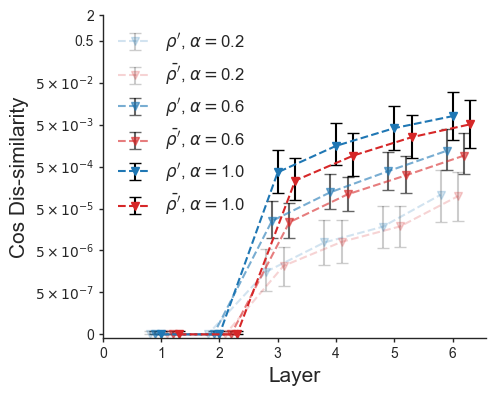

In [54]:
fig, ax = plt.subplots(1, figsize=(5, 4))

for i, rho_scale in enumerate(Rho_scales):
    CosDisSimW, CosDisSimW2 = [], []
    for j in range(nLP-1):
        CosDisSimW.append(np.clip(1-CosSimW[i][nLP-j-1], 5e-8, 2))
        CosDisSimW2.append(np.clip(1-CosSimW2[i][nLP-j-1], 5e-8, 2))
    plotCosDis(CosDisSimW, rho_scale, v=1, num=nLP-1, ax=ax)
    plotCosDis(CosDisSimW2, rho_scale, v=2, num=nLP-1, ax=ax)

ax.set_yscale("log")
ax.set_ylim(4e-8, 1)
ax.set_ylabel("Cos Dis-similarity", fontsize=15)
ax.set_xlabel("Layer", fontsize=15)
ax.set_xlabel("Layer", fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(nLP)-1, np.arange(nLP))
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_yticks([5e-8, 5e-7, 5e-6, 5e-5, 5e-4, 5e-3, 5e-2, 5e-1, 2], 
                  [0, r"$5\times 10^{-7}$", r"$5\times 10^{-6}$", r"$5\times 10^{-5}$", 
                   r"$5\times 10^{-4}$", r"$5\times 10^{-3}$", r"$5\times 10^{-2}$",  0.5, 2])
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/GradCosSimLayer.png')
plt.show()

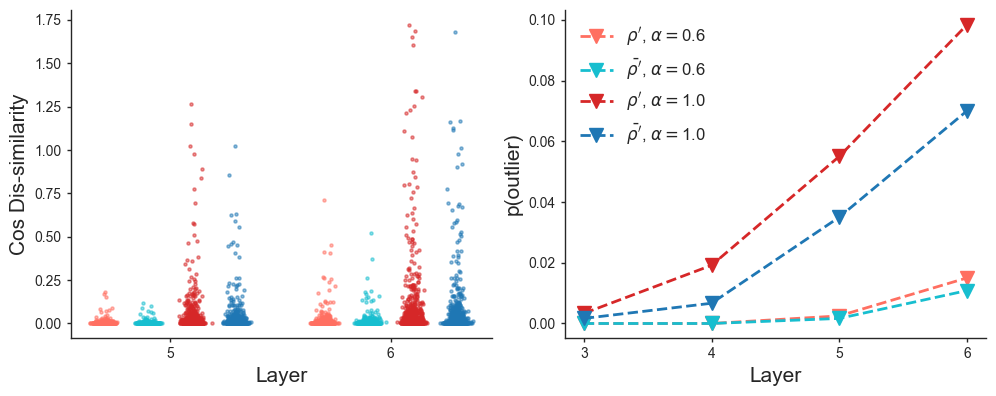

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
start_l = 4
for i, rho_scale in enumerate(Rho_scales):
    CosDisSimW, CosDisSimW2 = [], []
    OL1, OL2 = [], []
    if i == 0:
        continue
    for j in range(nLP-1):
        CosDisSimW.append(np.clip(1-CosSimW[i][nLP-j-1], 5e-8, 2))
        CosDisSimW2.append(np.clip(1-CosSimW2[i][nLP-j-1], 5e-8, 2))
        num_outlier = (CosDisSimW[-1] > 0.1).sum()
        num_outlier2 = (CosDisSimW2[-1] > 0.1).sum()
        OL1.append(num_outlier/len(CosDisSimW[-1]))
        OL2.append(num_outlier2/len(CosDisSimW[-1]))
    clr1 = pink if i==1 else red
    clr2 = teal if i==1 else blue
    axs[1].plot(OL1[2:], color = clr1, marker='v', markersize=10, linestyle='--', linewidth=2, label=r"$\rho'$, $\alpha=$%.1f"%rho_scale)
    axs[1].plot(OL2[2:], color = clr2, marker='v', markersize=10, linestyle='--', linewidth=2, label=r"$\bar{\rho'}$, $\alpha=$%.1f"%rho_scale)
    x1 = np.arange(nLP-start_l-1)+0.2*(2*i-3)-0.1
    x2 = np.arange(nLP-start_l-1)+0.2*(2*i-3)+0.1
    #axs[0].violinplot(CosDisSimW[start_l:], positions=x1)
    #axs[0].violinplot(CosDisSimW2[start_l:], positions=x2)
    for j, d in enumerate(CosDisSimW[start_l:]):
        x_scat = np.random.normal(x1[j], 0.02, size=len(d))  # small horizontal jitter
        axs[0].scatter(x_scat, d, alpha=0.5, s=5, color=clr1)
    for j, d in enumerate(CosDisSimW2[start_l:]):
        x_scat = np.random.normal(x2[j], 0.02, size=len(d))  # small horizontal jitter
        axs[0].scatter(x_scat, d, alpha=0.5, s=5, color=clr2)

axs[0].set_xticks(np.arange(nLP-start_l-1), np.arange(nLP-start_l-1)+start_l+1)
axs[1].set_xticks(np.arange(nLP-3), np.arange(nLP-3)+3)
for i in range(2):
    axs[i].set_xlabel("Layer", fontsize=15)
    axs[i].set_xlabel("Layer", fontsize=15)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].tick_params(axis='both', which='major', labelsize=10)
axs[0].set_ylabel("Cos Dis-similarity", fontsize=15)
axs[1].set_ylabel("p(outlier)", fontsize=15)

axs[1].legend(fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/GradOutlier.png')
plt.show()

### With rho/layers

In [6]:
model_config["LP_size"] = [60, 60, 60, 60, 60, 60, 60]
model_config["num_LP_layers"] = 7
model_config["num_Ins_layers"] = 0
model_config['Tau1'] = [2.2, 3.2, 5.2]
model_config['Tau2'] = [2.1, 3.1, 5.1]
model_config['Tau3'] = [2., 3., 5.]
model_config['Tau4'] = [1.9, 2.9, 4.9]
model_config['Tau5'] = [1.8, 2.8, 4.8]
model_config['Tau6'] = [1.7, 2.7, 4.7]
model_config["version"] = 0
model_config["rho_scale"] = 1.
train_config["batch_size"] = 1

nLP = model_config['num_LP_layers']
CosSim = torch.nn.CosineSimilarity(dim=-1, eps=1e-6)
num_repeat = 50
Activations = ["tanh", "sigmoid", "relu"] #?silu
CosSimW, CosSimW2 = [], []

for activation in Activations:
    model_config["activation"] = activation
    model_config["rho_scale"] = 2 if activation=="sigmoid" else 1
    CosSimW_record = [[] for _ in range(nLP)]
    CosSimW2_record = [[] for _ in range(nLP)]
    for _ in range(num_repeat):
        model = buildKPNet(model_config, general_config)
        ##### assigned tau to LP rho'###
        # tau = 14
        for l in model.layers[:nLP]:
            l.dt_tau_rho = l.dt_tau#1 / tau
            l.decay_rho = 1 - l.dt_tau_rho
        #     tau -= 2
        ##################################
        idx = (np.random.permutation(4000).reshape(-1, train_config["batch_size"]))[0]
        sample_batch_x = x[idx]
        one_hot_label = one_hot_label = F.one_hot(y[idx], num_classes=10)
        model.reset()
        GradW_all_time = [[] for _ in range(nLP)]
        GradW2_all_time = [[] for _ in range(nLP)]
        total_loss = 0.
        for t in range(n_steps):
            r_out,_ = model.step(sample_batch_x[:, t])
            if n_steps-t <= answer_steps:
                p = torch.softmax(r_out, dim=1)
                loss_t = -(one_hot_label * torch.log(p)).mean(dim=0).sum()*beta[t]
                total_loss += loss_t
                if beta[t] != 0:
                    error = (one_hot_label - p)*beta[t]
                    model.prop(error=error)
                    for i in reversed(range(nLP)):
                        (dW, dW2), (db, db2) = model.layers[i].comp_grad()
                        GradW_all_time[i].append(dW.detach())
                        GradW2_all_time[i].append(dW2.detach())
                else:
                    model.prop(learn=False)
            else:
                model.prop(learn=False)
                
        model.zero_grad()       
        total_loss.backward()
        for i in range(nLP):
            GradW_all_time[i] = torch.stack(GradW_all_time[i])
            GradW2_all_time[i] = torch.stack(GradW2_all_time[i])
            if i==0:
                cos_sim = CosSim(model.layers[i].W_in.grad.T, GradW_all_time[i].sum(dim=0).T).detach()
                cos_sim2 = CosSim(model.layers[i].W_in.grad.T, GradW2_all_time[i].sum(dim=0).T).detach()
            else:
                cos_sim = CosSim(model.layers[i].W_in.grad, GradW_all_time[i].sum(dim=0)).detach()
                cos_sim2 = CosSim(model.layers[i].W_in.grad, GradW2_all_time[i].sum(dim=0)).detach()
            CosSimW_record[i].append(cos_sim)
            CosSimW2_record[i].append(cos_sim2)
    
    for i in range(nLP):
        CosSimW_record[i] = torch.hstack(CosSimW_record[i]).numpy()
        CosSimW2_record[i] = torch.hstack(CosSimW2_record[i]).numpy()
        #print(CosSimW_record[i].shape, CosSimW_record[i].mean())
    CosSimW.append(CosSimW_record)
    CosSimW2.append(CosSimW2_record)

In [7]:
def plotCosDis(cos_dissim, activation, v, num, ax):
    means, low, high = [], [], []
    
    for i in range(num):
        d = cos_dissim[i].flatten()
    
        med = np.median(d)
        p25 = np.percentile(d, 25)
        p75 = np.percentile(d, 75)
    
        means.append(med)
        low.append(med - p25)
        high.append(p75 - med)

    x = np.arange(num)-0.3 if v==1 else np.arange(num)+0.3
    x = np.arange(num)-0.15 if v==1 else np.arange(num)+0.15
    if activation == "tanh":
        x -= 0.1
        color = teal
        activation_name = 'Tanh'
    elif activation == "sigmoid":
        x += 0.15
        activation_name = 'Logistic'
        color = lightgreen
    elif activation == "relu":
        x += 0.4
        color = pink
        activation_name = 'ReLU'
    alpha = 0.4 if v==1 else 1
    label = r"$\rho', $" if v==1 else r"$\bar{\rho'}$, "
    label += activation_name
    ax.errorbar(
        x,
        means,
        yerr=[low, high],
        fmt='v',
        capsize = 3,
        label = label,
        color = color,
        alpha = alpha,
        ls='--', 
        capthick=1, 
        ecolor='black',
        markersize=8,
    )

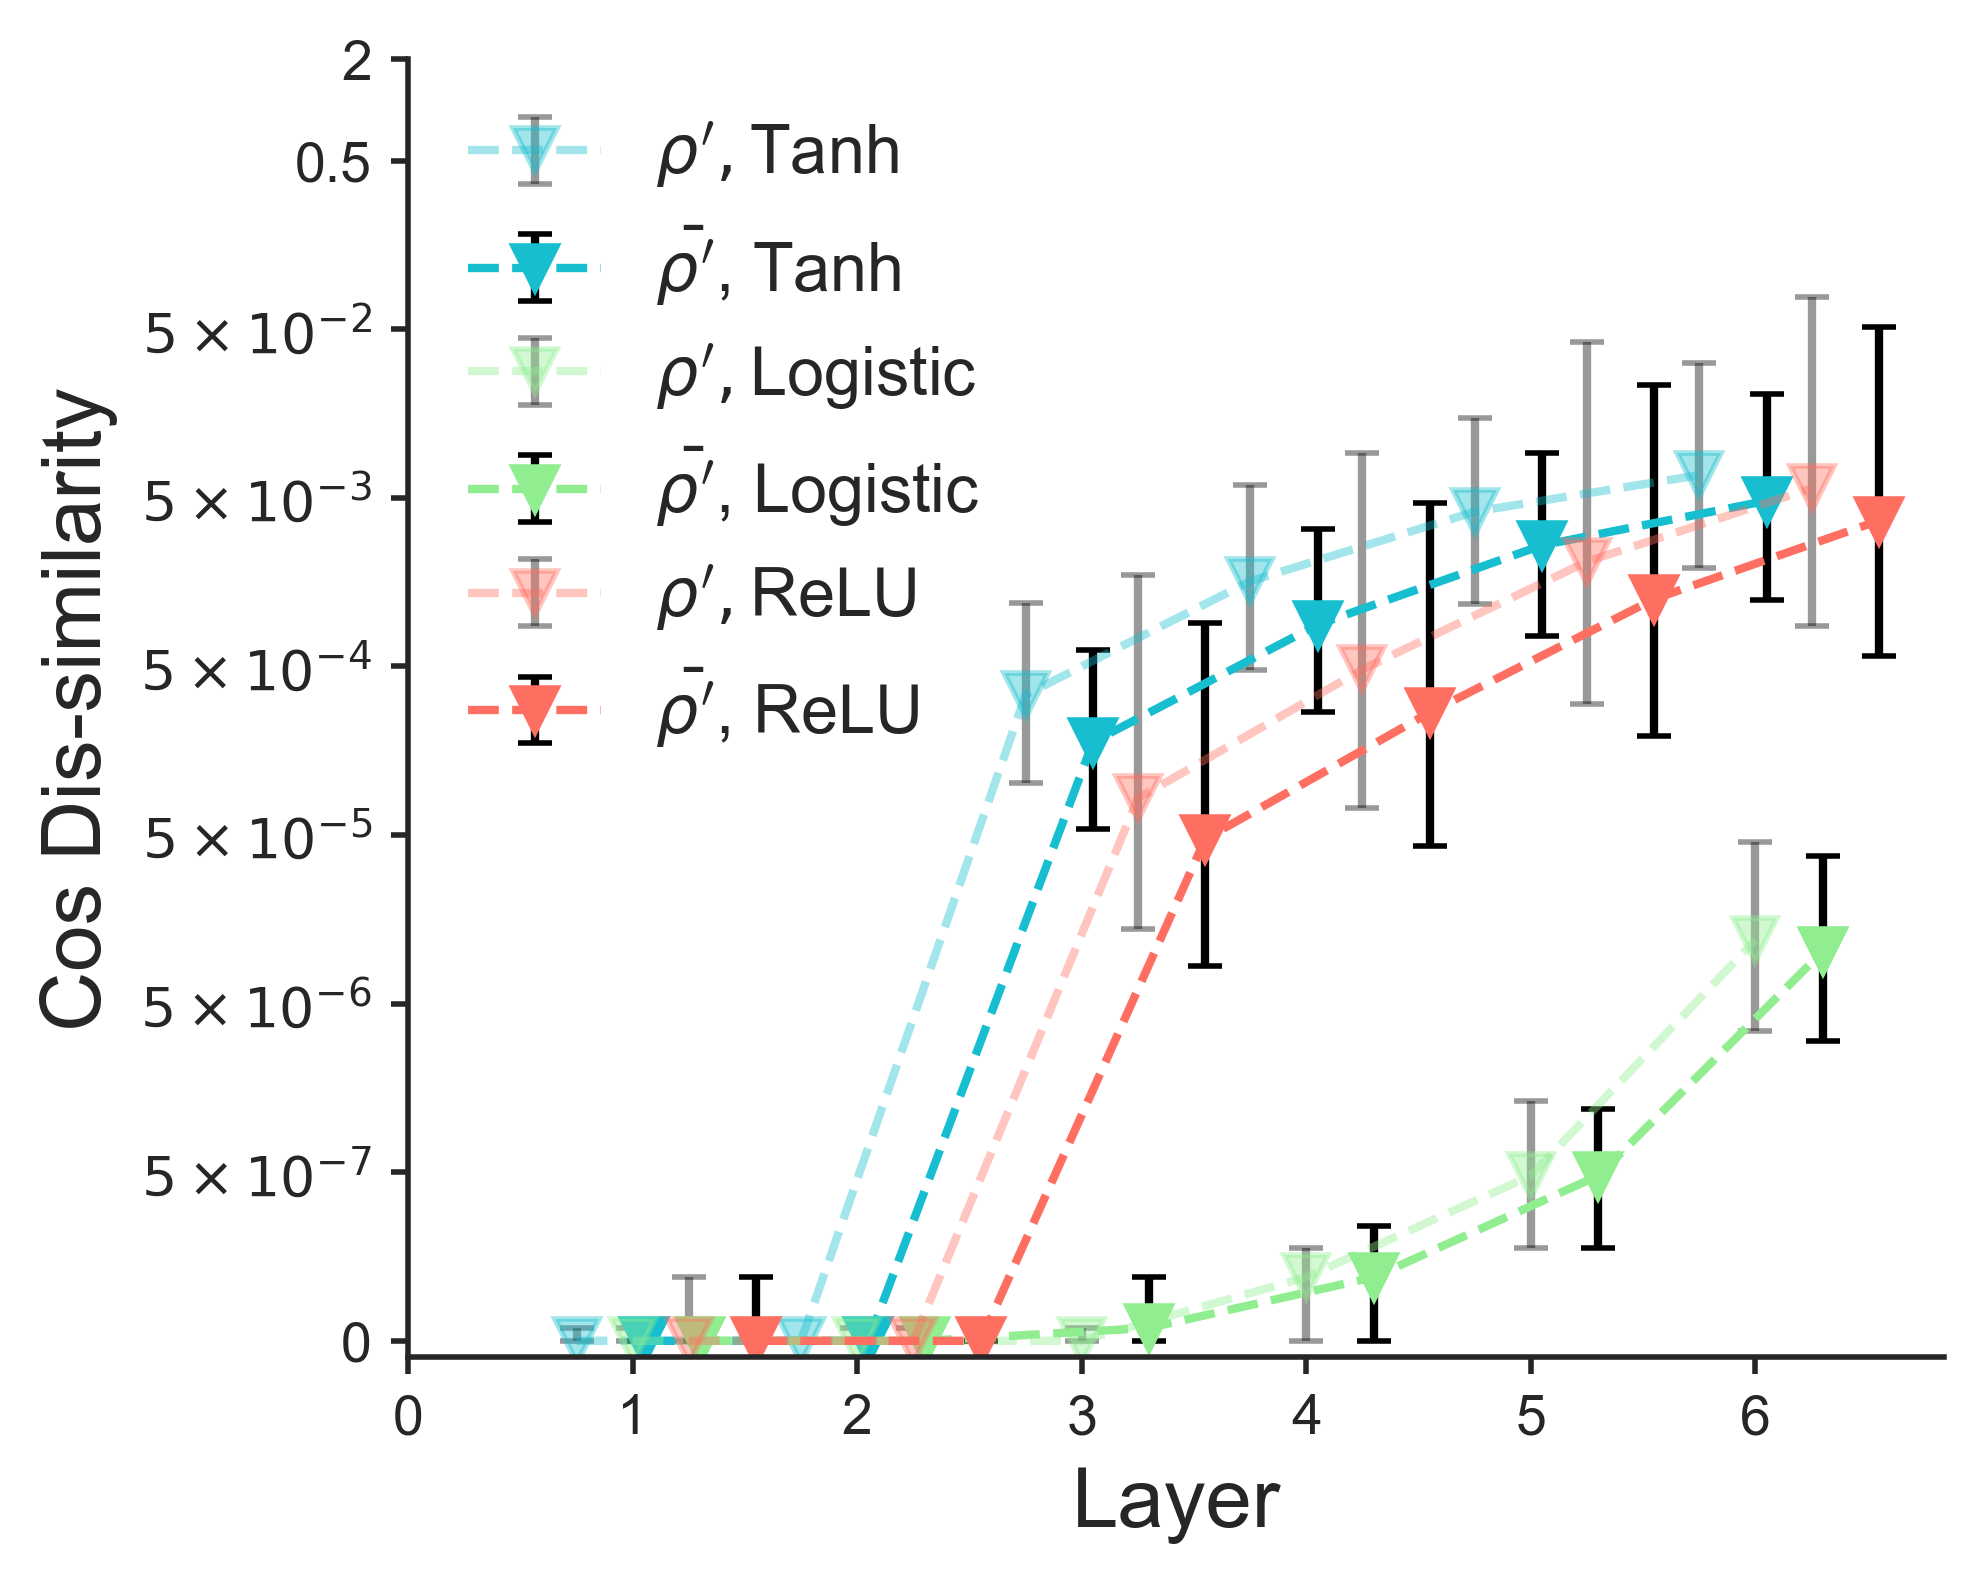

In [11]:
fig, ax = plt.subplots(1, figsize=(5, 4), dpi=400)

for i, activation in enumerate(Activations):
    CosDisSimW, CosDisSimW2 = [], []
    for j in range(nLP-1):
        CosDisSimW.append(np.clip(1-CosSimW[i][nLP-j-1], 5e-8, 2))
        CosDisSimW2.append(np.clip(1-CosSimW2[i][nLP-j-1], 5e-8, 2))
    plotCosDis(CosDisSimW, activation, v=1, num=nLP-1, ax=ax)
    plotCosDis(CosDisSimW2, activation, v=2, num=nLP-1, ax=ax)

ax.set_yscale("log")
ax.set_ylim(4e-8, 1)
ax.set_ylabel("Cos Dis-similarity", fontsize=15)
ax.set_xlabel("Layer", fontsize=15)
ax.set_xlabel("Layer", fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(nLP)-1, np.arange(nLP))
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_yticks([5e-8, 5e-7, 5e-6, 5e-5, 5e-4, 5e-3, 5e-2, 5e-1, 2], 
                  [0, r"$5\times 10^{-7}$", r"$5\times 10^{-6}$", r"$5\times 10^{-5}$", 
                   r"$5\times 10^{-4}$", r"$5\times 10^{-3}$", r"$5\times 10^{-2}$",  0.5, 2])
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/GradCosSimActi.png')
plt.show()

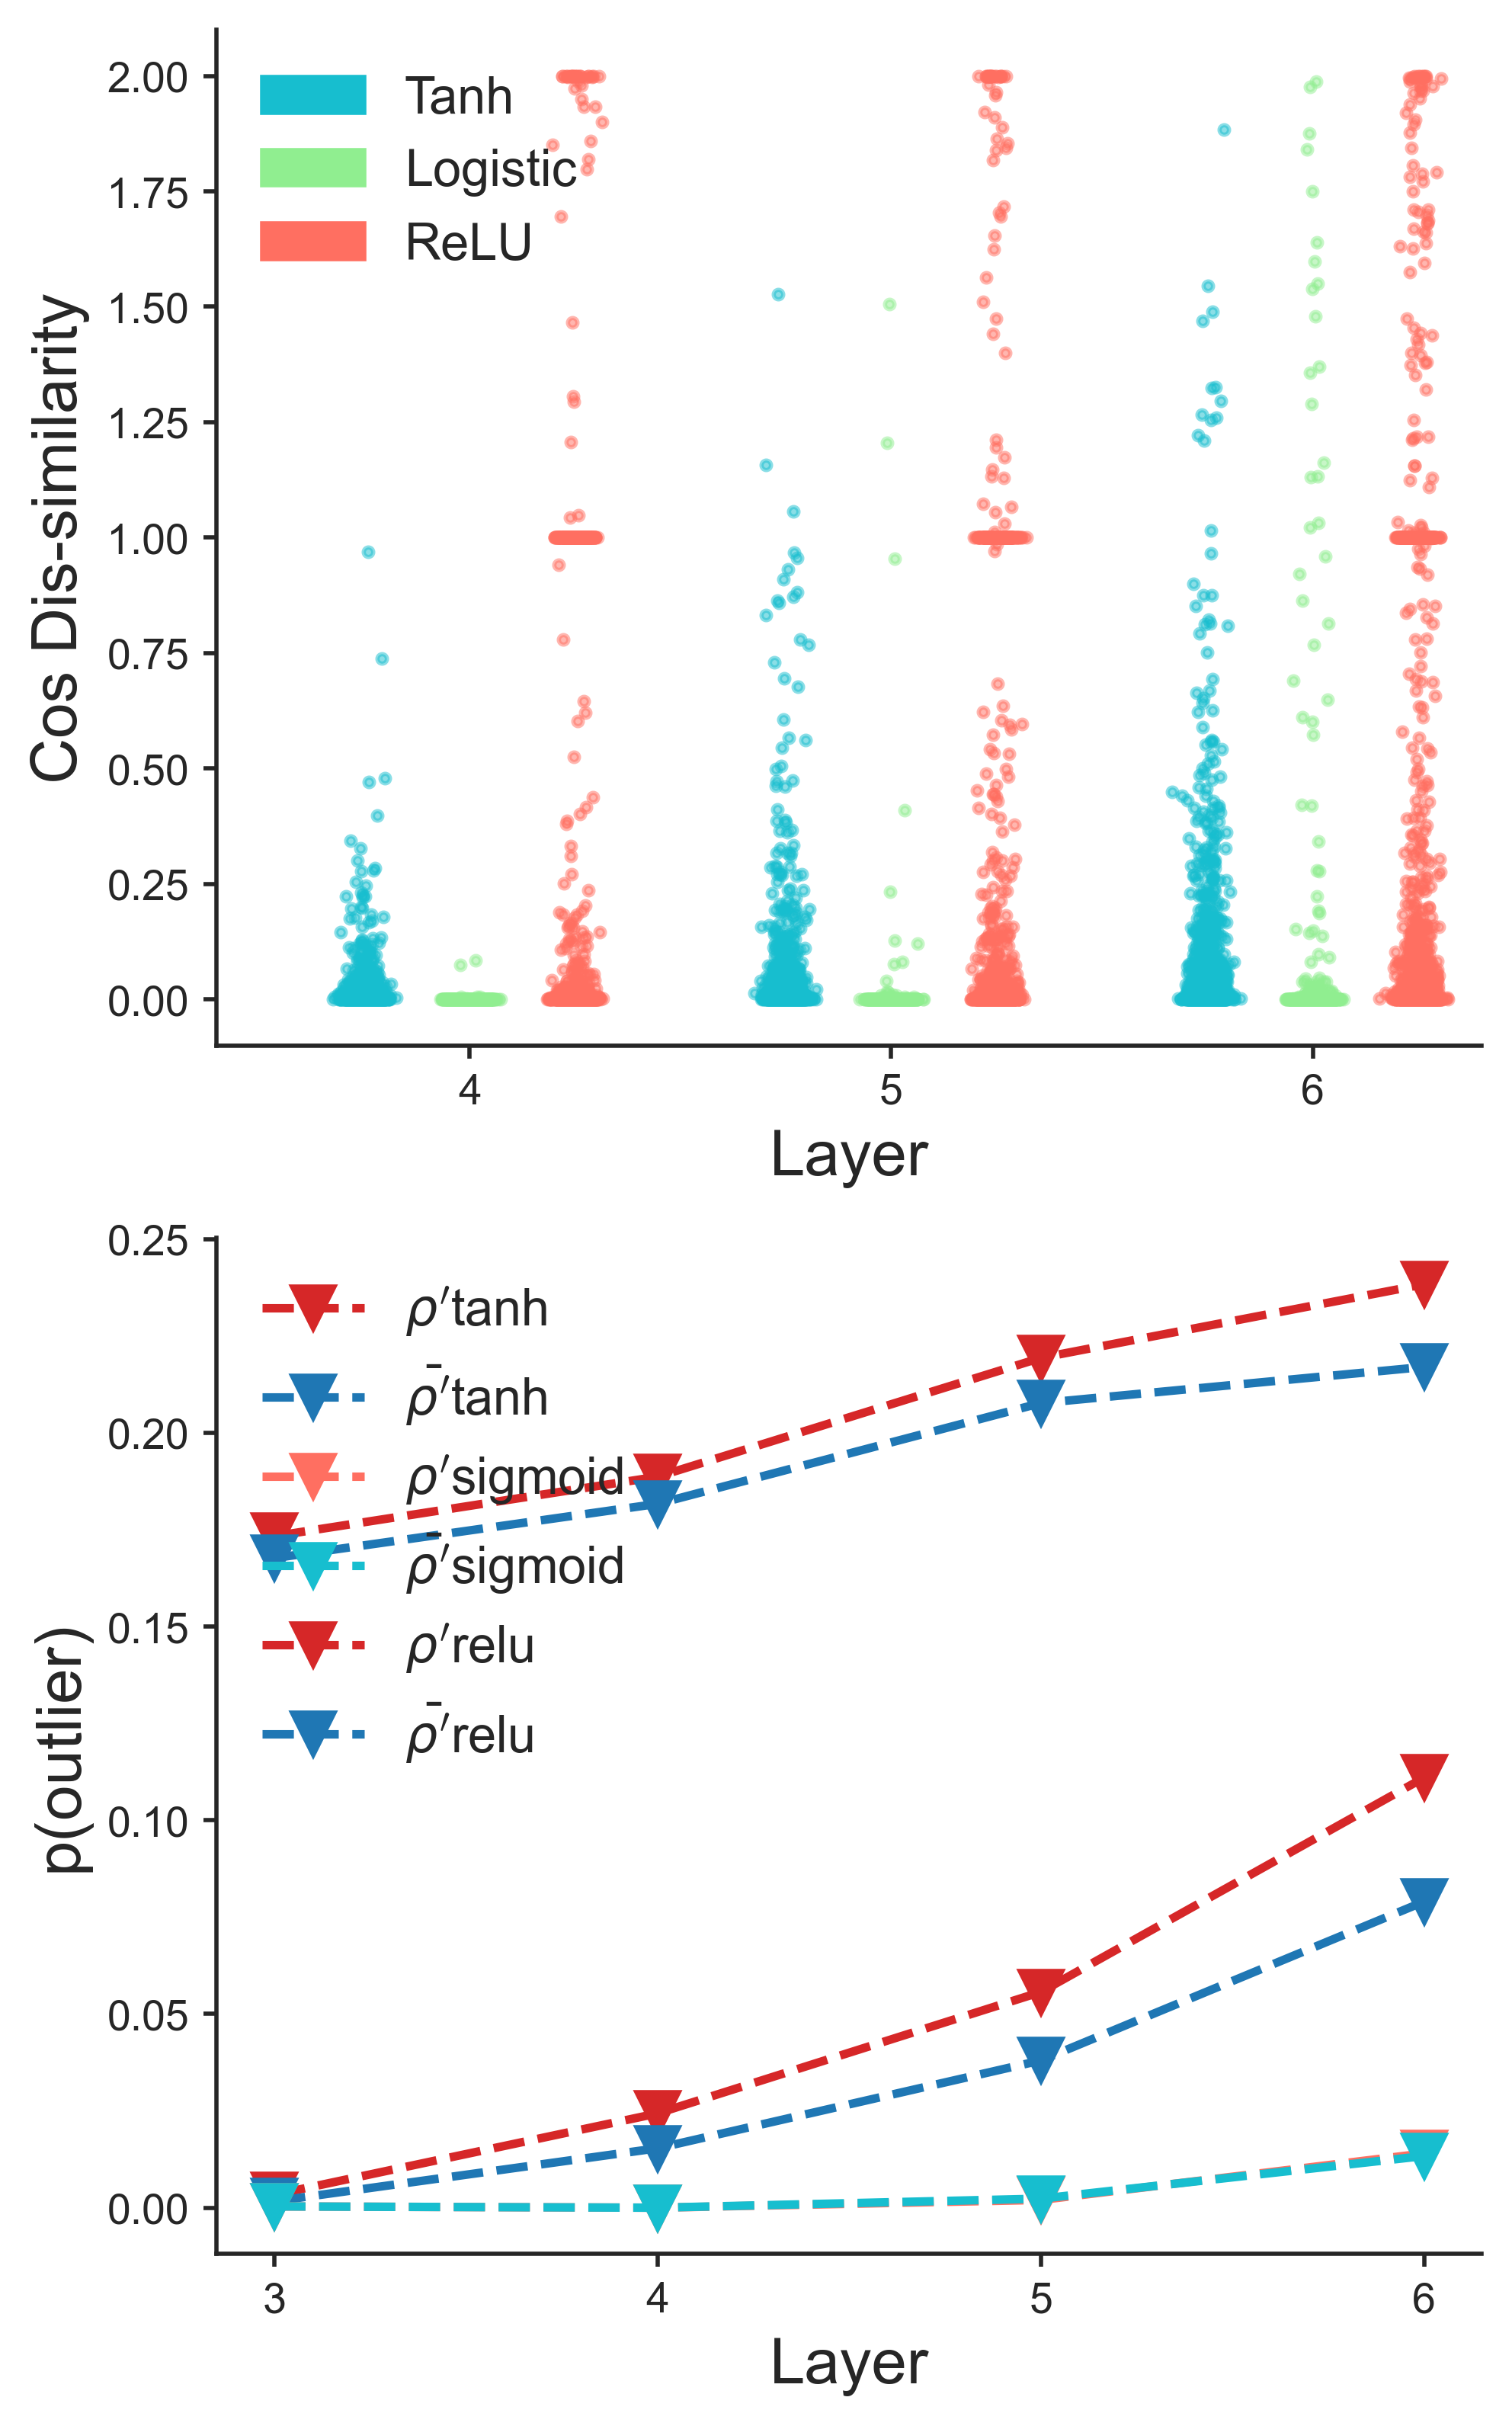

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(5, 8), dpi=400)
start_l = 3
colors = [teal, lightgreen, pink]
xs = [-0.25, 0., 0.25]
for i, activation in enumerate(Activations):
    CosDisSimW, CosDisSimW2 = [], []
    OL1, OL2 = [], []
    for j in range(nLP-1):
        CosDisSimW.append(np.clip(1-CosSimW[i][nLP-j-1], 5e-8, 2))
        CosDisSimW2.append(np.clip(1-CosSimW2[i][nLP-j-1], 5e-8, 2))
        num_outlier = (CosDisSimW[-1] > 0.1).sum()
        num_outlier2 = (CosDisSimW2[-1] > 0.1).sum()
        OL1.append(num_outlier/len(CosDisSimW[-1]))
        OL2.append(num_outlier2/len(CosDisSimW[-1]))
        
    clr1 = pink if i==1 else red
    clr2 = teal if i==1 else blue
    axs[1].plot(OL1[2:], color = clr1, marker='v', markersize=10, linestyle='--', linewidth=2, label=r"$\rho'$"+activation)
    axs[1].plot(OL2[2:], color = clr2, marker='v', markersize=10, linestyle='--', linewidth=2, label=r"$\bar{\rho'}$"+activation)
    
    x2 = np.arange(nLP-start_l-1)+xs[i]
    for j, d in enumerate(CosDisSimW2[start_l:]):
        x_scat = np.random.normal(x2[j], 0.02, size=len(d))  # small horizontal jitter
        axs[0].scatter(x_scat, d, alpha=0.5, s=5, color=colors[i])

axs[0].set_xticks(np.arange(nLP-start_l-1), np.arange(nLP-start_l-1)+start_l+1)
axs[1].set_xticks(np.arange(nLP-3), np.arange(nLP-3)+3)
for i in range(2):
    axs[i].set_xlabel("Layer", fontsize=15)
    axs[i].set_xlabel("Layer", fontsize=15)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].tick_params(axis='both', which='major', labelsize=10)
axs[0].set_ylabel("Cos Dis-similarity", fontsize=15)
axs[1].set_ylabel("p(outlier)", fontsize=15)

handles = [
    plt.Rectangle((0, 0), 0.5, 0.5, color=colors[0], label='Tanh'),
    plt.Rectangle((0, 0), 0.5, 0.5, color=colors[1], label='Logistic'),
    plt.Rectangle((0, 0), 0.5, 0.5, color=colors[2], label='ReLU'),
]
# Legend inside plot box
axs[0].legend(handles=handles, loc='upper left', frameon=False, fontsize=12)
axs[0].set_xlim(-0.6, 2.4)

axs[1].legend(fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/GradOutlierActivation.png')
plt.show()

### With tau

In [5]:
model_config["LP_size"] = [60, 60, 60, 60]
model_config["num_LP_layers"] = 4
model_config["num_Ins_layers"] = 0
model_config["version"] = 0
train_config["batch_size"] = 1
Rho_scales = [0.2, 0.6, 1.]
Tau3 = np.array([2.5])
CosDisSimW, CosDisSimW2 = [[], [], []], [[], [], []]

nLP = model_config['num_LP_layers']
CosSim = torch.nn.CosineSimilarity(dim=-1, eps=1e-6)

CosSimW_record = {}
CosSimW2_record = {}
num_repeat = 20
num_tau = 9

for _ in range(num_tau):
    model_config['Tau3'] = Tau3
    for idx_rho, rho_scale in enumerate(Rho_scales):
        CosSimW = []
        CosSimW2 = []
        model_config["rho_scale"] = rho_scale
        for _ in range(num_repeat):
            model = buildKPNet(model_config, general_config)
            for l in model.layers[:nLP]:
                l.dt_tau_rho = l.dt_tau#1 / tau
                l.decay_rho = 1 - l.dt_tau_rho
            idx = (np.random.permutation(4000).reshape(-1, train_config["batch_size"]))[0]
            sample_batch_x = x[idx]
            one_hot_label = one_hot_label = F.one_hot(y[idx], num_classes=10)
            model.reset()
            GradW_all_time = []
            GradW2_all_time = []
            total_loss = 0.
            for t in range(n_steps):
                r_out,_ = model.step(sample_batch_x[:, t])
                if n_steps-t <= answer_steps:
                    p = torch.softmax(r_out, dim=1)
                    loss_t = -(one_hot_label * torch.log(p)).mean(dim=0).sum()*beta[t]
                    total_loss += loss_t
                    if beta[t] != 0:
                        error = (one_hot_label - p)*beta[t]
                        model.prop(error=error)
                        for i in reversed(range(1, nLP)):
                            (dW, dW2), (db, db2) = model.layers[i].comp_grad()
                        GradW_all_time.append(dW.detach())
                        GradW2_all_time.append(dW2.detach())
                    else:
                        model.prop(learn=False)
                    
                else:
                    model.prop(learn=False)
                    
            model.zero_grad()       
            total_loss.backward()
            GradW_all_time = torch.stack(GradW_all_time)
            GradW2_all_time = torch.stack(GradW2_all_time)
            cos_sim = CosSim(model.layers[1].W_in.grad, GradW_all_time.sum(dim=0)).detach()
            cos_sim2 = CosSim(model.layers[1].W_in.grad, GradW2_all_time.sum(dim=0)).detach()
            CosSimW.append(cos_sim)
            CosSimW2.append(cos_sim2)
        
        CosSimW_record[Tau3[0]] = torch.hstack(CosSimW).numpy()
        CosSimW2_record[Tau3[0]] = torch.hstack(CosSimW2).numpy()
        CosDisSimW[idx_rho].append(np.clip(1-CosSimW_record[Tau3[0]], 5e-8, 2))
        CosDisSimW2[idx_rho].append(np.clip(1-CosSimW2_record[Tau3[0]], 5e-8, 2))
    #print(Tau3[0], CosSimW_record[Tau3[0]].mean())
    Tau3 *= 2

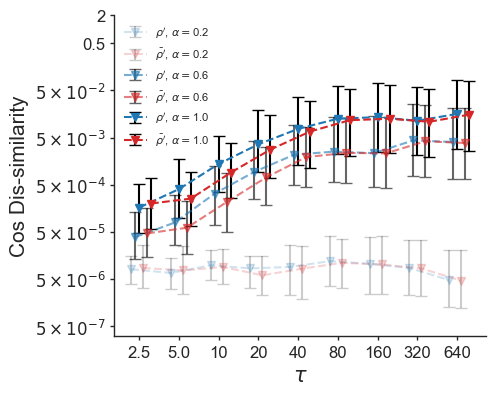

In [8]:
fig, ax = plt.subplots(1, figsize=(5, 4))


xticks = []
for tau in CosSimW_record.keys():
    if tau > 5:
        xticks.append(int(tau))
    else:
        xticks.append(tau)

for i, rho_scale in enumerate(Rho_scales):
    plotCosDis(CosDisSimW[i], rho_scale, v=1, num=num_tau, ax=ax)
    plotCosDis(CosDisSimW2[i], rho_scale, v=2, num=num_tau, ax=ax)

ax.set_yscale("log")
ax.set_ylim(3e-7, 1)
ax.set_ylabel("Cos Dis-similarity", fontsize=15)
ax.set_xlabel(r"$\tau$", fontsize=15)
ax.set_yticks([5e-7, 5e-6, 5e-5, 5e-4, 5e-3, 5e-2, 5e-1, 2], 
                  [r"$5\times 10^{-7}$", r"$5\times 10^{-6}$", r"$5\times 10^{-5}$", 
                   r"$5\times 10^{-4}$", r"$5\times 10^{-3}$", r"$5\times 10^{-2}$",  0.5, 2])
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(np.arange(num_tau), xticks)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig('../Figures/GradCosSimTau.png')
plt.show()

### With all $\tau$

In [13]:
model_config = dict(default_model_config)
model_config["LP_size"] = [60, 60, 60, 60]
model_config["num_LP_layers"] = 4
model_config["num_Ins_layers"] = 0
model_config["version"] = 0
train_config["batch_size"] = 1
Activations = ["tanh", "sigmoid", "relu"]
CosDisSimW, CosDisSimW2 = [[], [], []], [[], [], []]

model_config['Tau1'] = [1.2, 3.2]
model_config['Tau2'] = [1.1, 3.1]
model_config['Tau3'] = [1.3, 3.,]

nLP = model_config['num_LP_layers']
CosSim = torch.nn.CosineSimilarity(dim=-1, eps=1e-6)
num_repeat = 50
num_tau = 9
gradlayer = 1

for _ in range(num_tau):
    for k, activation in enumerate(Activations):
        model_config["activation"] = activation
        model_config["rho_scale"] = 2 if activation=="sigmoid" else 1.
        CosSimW, CosSimW2 = [], []
        for _ in range(num_repeat):
            model = buildKPNet(model_config, general_config)
            for l in model.layers[:nLP]:
                l.dt_tau_rho = l.dt_tau#1 / tau
                l.decay_rho = 1 - l.dt_tau_rho
            idx = (np.random.permutation(4000).reshape(-1, train_config["batch_size"]))[0]
            sample_batch_x = x[idx]
            one_hot_label = F.one_hot(y[idx], num_classes=10)
            model.reset()
            GradW_all_time = []
            GradW2_all_time = []
            total_loss = 0.
            for t in range(n_steps):
                r_out,_ = model.step(sample_batch_x[:, t])
                if n_steps-t <= answer_steps:
                    p = torch.softmax(r_out, dim=1)
                    loss_t = -(one_hot_label * torch.log(p)).mean(dim=0).sum()*beta[t]
                    total_loss += loss_t
                    if beta[t] != 0:
                        error = (one_hot_label - p)*beta[t]
                        model.prop(error=error)
                        for i in reversed(range(gradlayer, nLP)):
                            (dW, dW2), (db, db2) = model.layers[i].comp_grad()
                        GradW_all_time.append(dW.detach())
                        GradW2_all_time.append(dW2.detach())            
                    else:
                        model.prop(learn=False)
                else:
                    model.prop(learn=False)       
            model.zero_grad()    
            total_loss.backward()
            GradW_all_time = torch.stack(GradW_all_time)
            GradW2_all_time = torch.stack(GradW2_all_time)
            cos_sim = CosSim(model.layers[gradlayer].W_in.grad, GradW_all_time.sum(dim=0)).detach()
            cos_sim2 = CosSim(model.layers[gradlayer].W_in.grad, GradW2_all_time.sum(dim=0)).detach()
            #print(model.layers[gradlayer].W_in.grad.sum(), GradW2_all_time.sum())
            CosSimW.append(cos_sim)
            CosSimW2.append(cos_sim2)
        
        CosSimW = torch.hstack(CosSimW).numpy()
        CosSimW2 = torch.hstack(CosSimW2).numpy()        
        CosDisSimW[k].append(np.clip(1-CosSimW, 5e-8, 2))
        CosDisSimW2[k].append(np.clip(1-CosSimW2, 5e-8, 2))
    for tau in ['Tau1', 'Tau2', 'Tau3']:
        model_config[tau] = 2*np.array(model_config[tau])
    model_config["Tau0"][0] *= 2
    model_config["Tau0"][1] *= 2

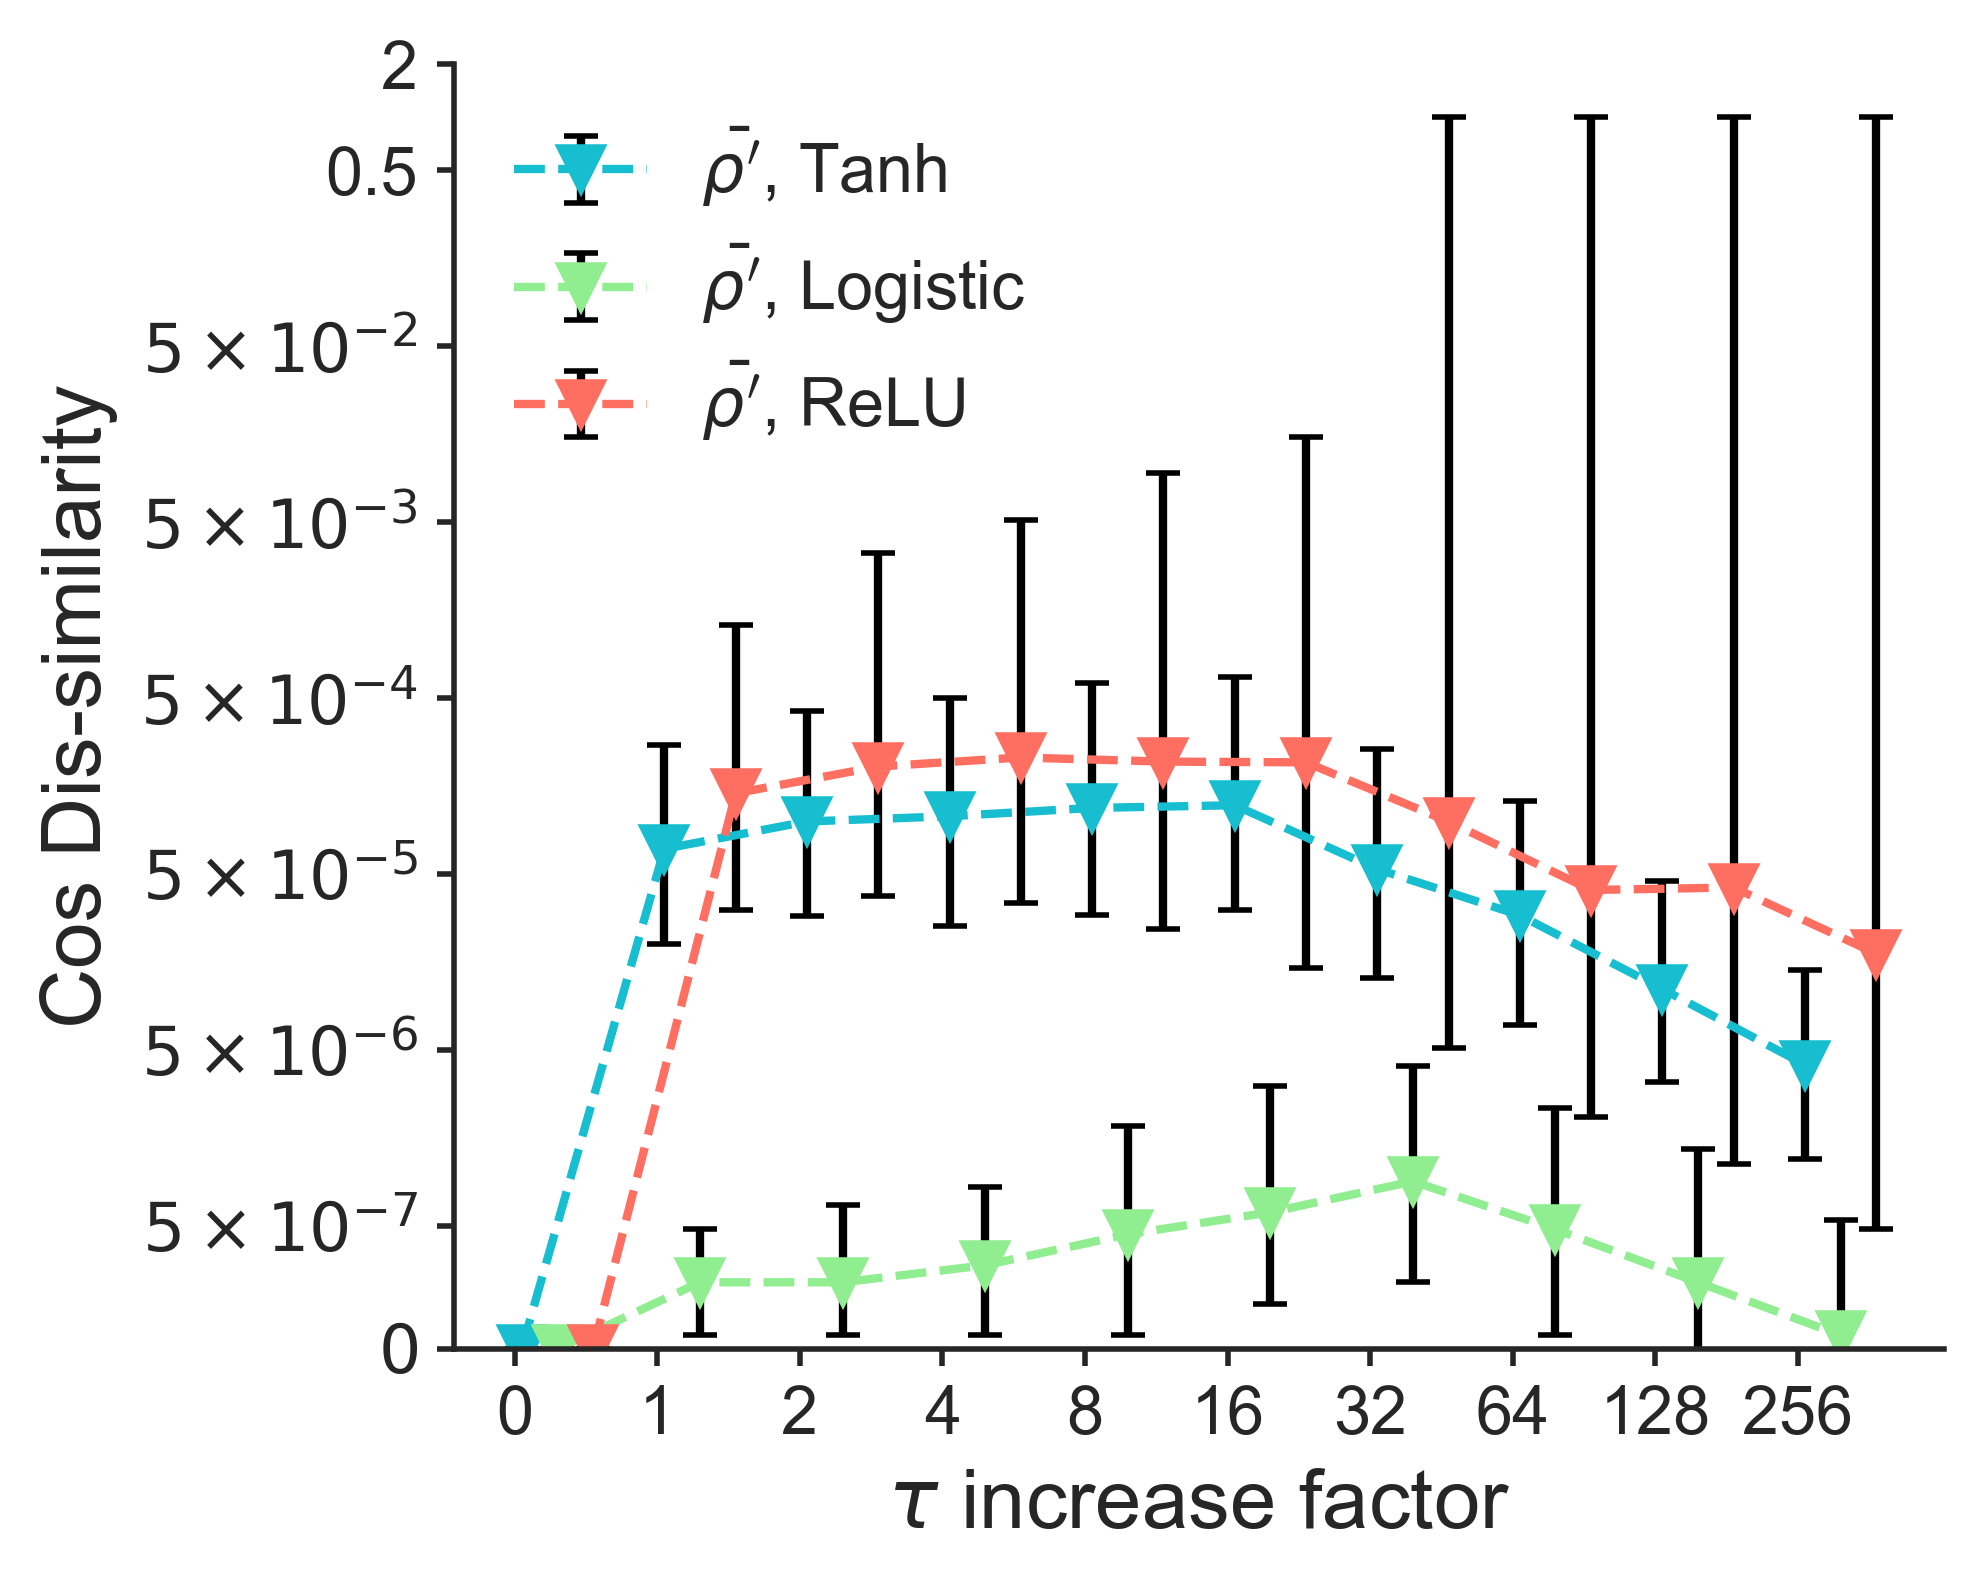

In [18]:
fig, ax = plt.subplots(1, figsize=(5, 4), dpi=400)
xticks = [int(2**i) for i in range(num_tau)]
xticks.insert(0, 0)
for i, activation in enumerate(Activations):
    if len(CosDisSimW2[i]) == num_tau:
        CosDisSimW2[i].insert(0, np.zeros_like(CosDisSimW2[i][-1])+1e-7)
    plotCosDis(CosDisSimW2[i], activation, v=2, num=num_tau+1, ax=ax)

ax.set_yscale("log")
ax.set_ylim(3e-7, 1)
ax.set_ylabel("Cos Dis-similarity", fontsize=15)
ax.set_xlabel(r"$\tau$ increase factor", fontsize=15)
ax.set_yticks([1e-7, 5e-7, 5e-6, 5e-5, 5e-4, 5e-3, 5e-2, 5e-1, 2], 
                  [r"$0$", r"$5\times 10^{-7}$", r"$5\times 10^{-6}$", r"$5\times 10^{-5}$", 
                   r"$5\times 10^{-4}$", r"$5\times 10^{-3}$", r"$5\times 10^{-2}$",  0.5, 2])
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(np.arange(num_tau+1), xticks)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/GradCosSimTau.png')
plt.show()

In [9]:
model_config["Tau0"]

[1, 10, 6]

## Ploting

seeds [0, 42, 428, 781, 3407, 115, 256, 666]

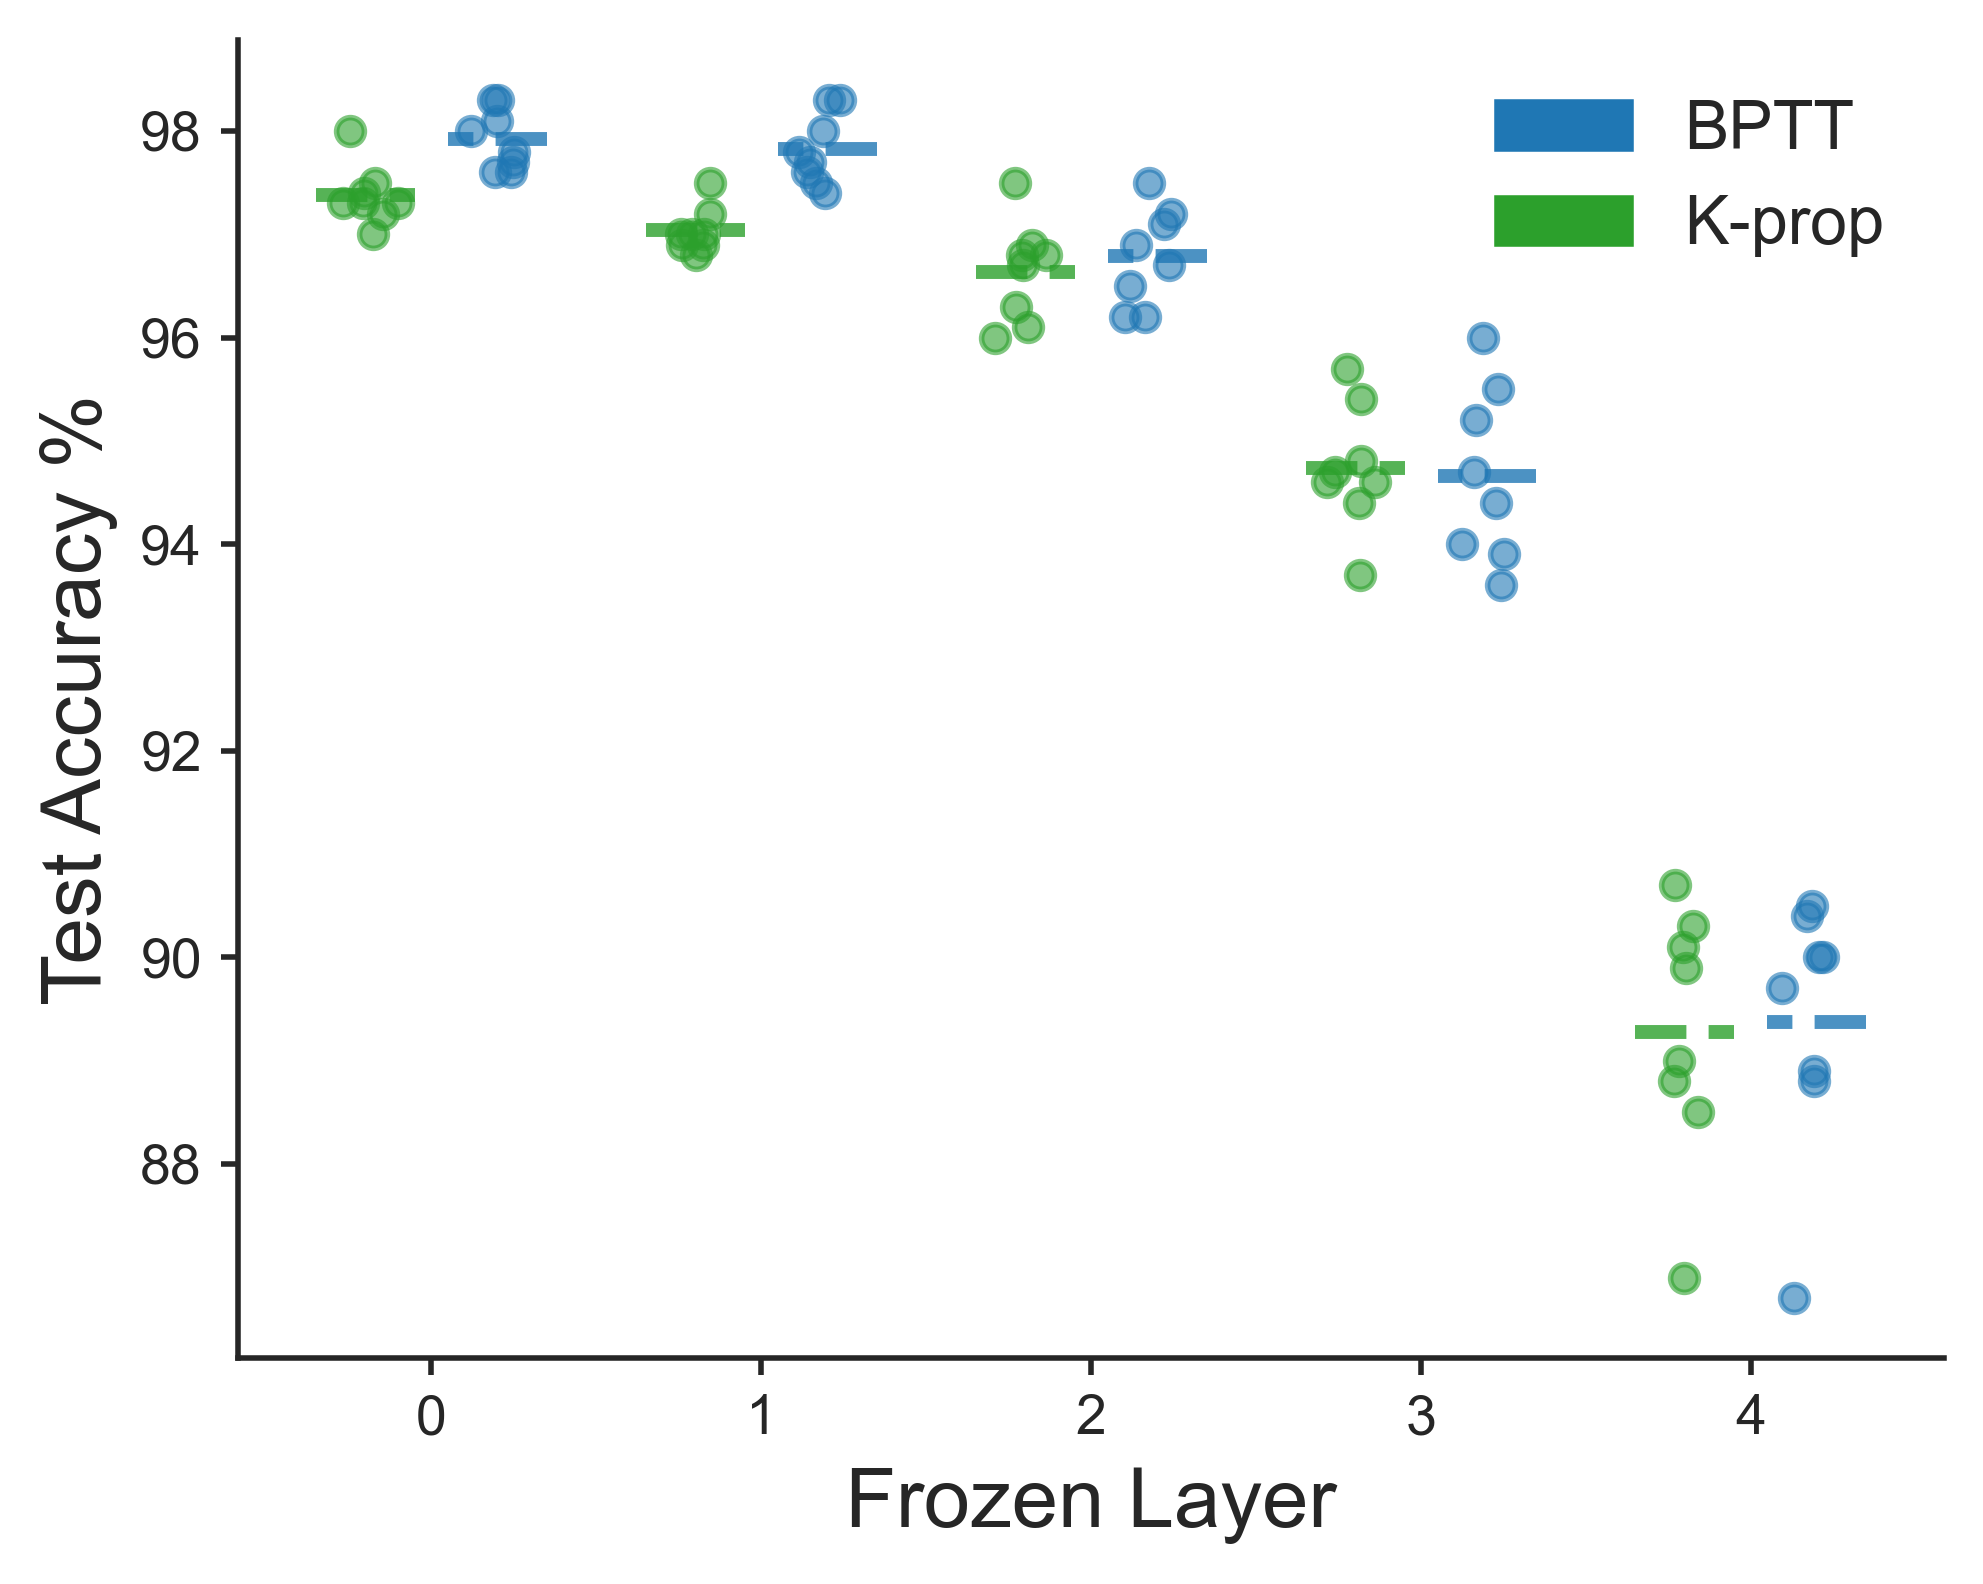

In [2]:
### Freeze Depth
KP_acc = np.array([[97.3, 97.2, 97.3, 97, 97.3, 98, 97.5, 97.4], 
                   [97, 97.2, 97.5, 97, 96.9, 97, 96.9, 96.8], 
                   [97.5, 96.8, 96.9, 96.8, 96.7, 96.3, 96.1, 96], 
                   [95.4, 94.8, 95.7, 94.4, 94.7, 94.6, 94.6, 93.7], 
                   [90.3, 89.9, 90.1, 89, 88.5, 88.8, 90.7, 86.9]])

BPTT_acc = np.array([[98, 97.6, 97.6, 98.3, 97.8, 98.1, 98.3, 97.7], 
                     [98, 97.7, 97.6, 98.3, 97.8, 98.3, 97.4, 97.5], 
                     [97.5, 96.9, 97.2, 96.7, 97.1, 96.2, 96.5, 96.2], 
                     [96, 95.2, 95.5, 94.7, 94, 93.6, 94.4, 93.9], 
                     [90, 89.7, 90.5, 90.4, 88.8, 88.9, 90, 86.7]
                    ])

fig, ax = plt.subplots(1, figsize=(5, 4), dpi=400)

for i, d in enumerate(KP_acc):
    x = np.random.normal(i-0.2, 0.04, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.6, s=25, color = green)
    ax.hlines(d.mean(), xmin=i-0.35, xmax=i-0.05, linestyle='--', color = green,
              alpha = 0.8, linewidth=2.5)

for i, d in enumerate(BPTT_acc):
    x = np.random.normal(i+0.2, 0.04, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.6, s=25, color = blue)
    ax.hlines(d.mean(), xmin=i+0.35, xmax=i+0.05, linestyle='--', color = blue,
              alpha = 0.8, linewidth=2.5)

ax.set_ylabel("Test Accuracy %", fontsize=15)
ax.set_xlabel("Frozen Layer", fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(5), np.arange(5))
ax.set_yticks([88, 90, 92, 94, 96, 98])
ax.tick_params(axis='both', which='major', labelsize=10)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=blue, label='BPTT'),
    plt.Rectangle((0, 0), 1, 1, color=green, label='K-prop'),
]
# Legend inside plot box
ax.legend(handles=handles, loc='best', frameon=False, fontsize=12)
plt.tight_layout()
#plt.savefig('../Figures/FrozenLayer.png')
plt.show()

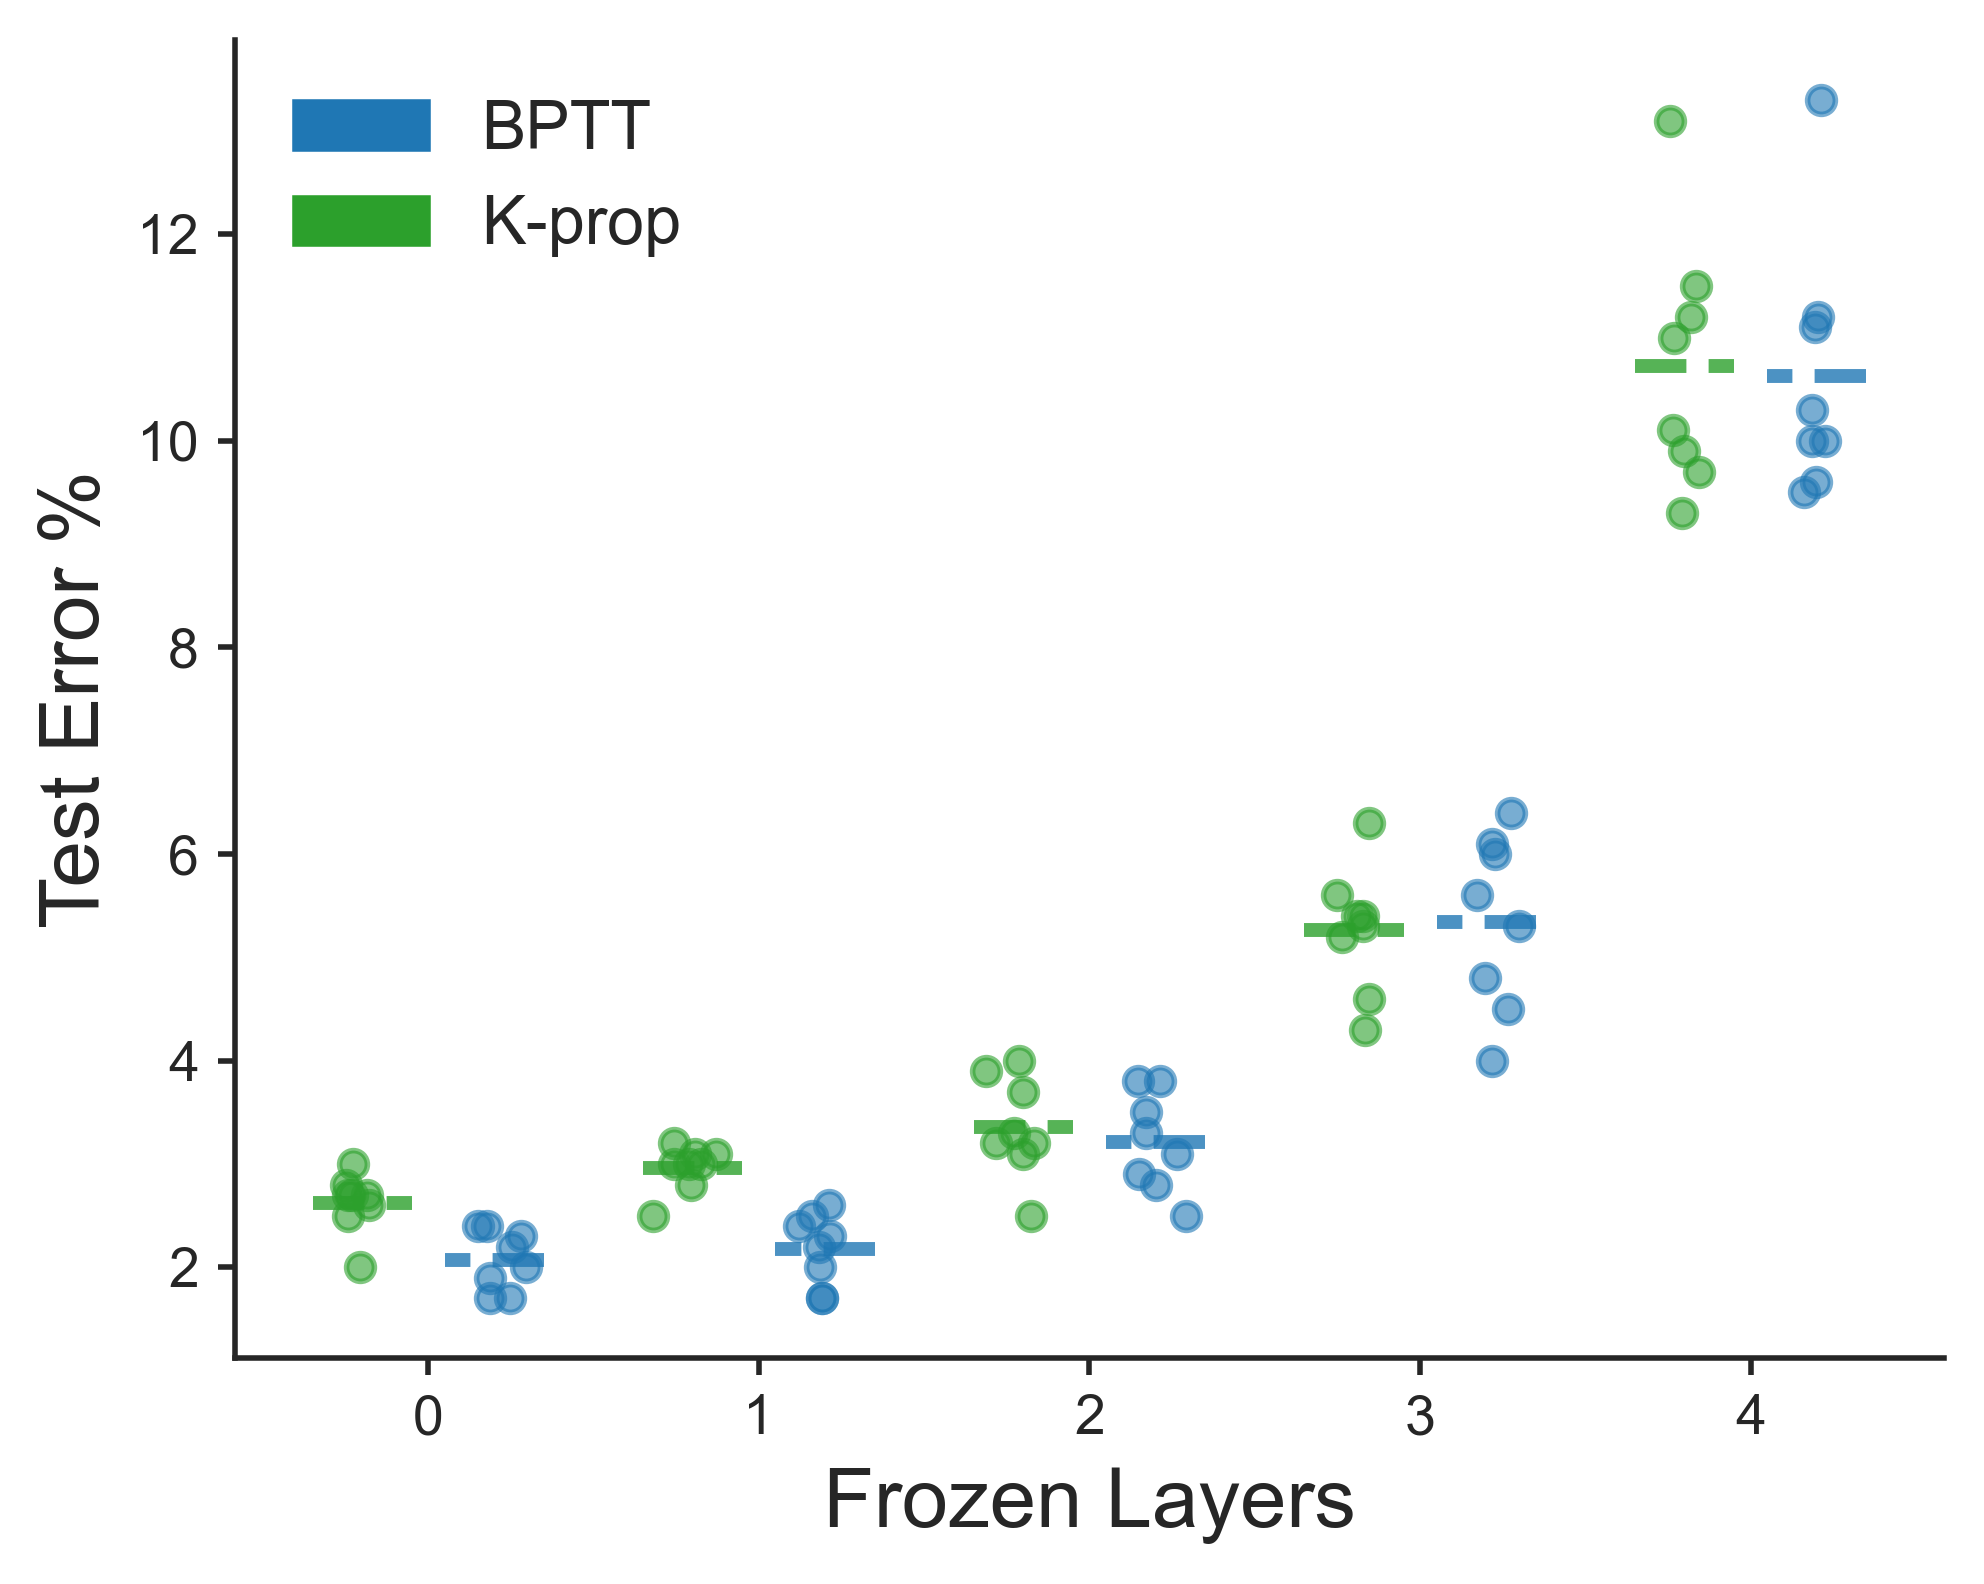

In [9]:
fig, ax = plt.subplots(1, figsize=(5, 4), dpi=400)
KP_err = 100 - KP_acc
BPTT_err = 100 - BPTT_acc

for i, d in enumerate(KP_err):
    x = np.random.normal(i-0.2, 0.05, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.6, s=25, color = green)
    ax.hlines(d.mean(), xmin=i-0.35, xmax=i-0.05, linestyle='--', color = green,
              alpha = 0.8, linewidth=2.5)

for i, d in enumerate(BPTT_err):
    x = np.random.normal(i+0.2, 0.05, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.6, s=25, color = blue)
    ax.hlines(d.mean(), xmin=i+0.35, xmax=i+0.05, linestyle='--', color = blue,
              alpha = 0.8, linewidth=2.5)

ax.set_ylabel("Test Error %", fontsize=15)
ax.set_xlabel("Frozen Layers", fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(5), np.arange(5))
#ax.set_yticks([88, 90, 92, 94, 96, 98])
ax.tick_params(axis='both', which='major', labelsize=10)

handles = [
    #plt.Circle((0, 0), 1, 1, color=blue, label='BPTT'),
    plt.Circle((0, 0), 1, color=blue, label='BPTT'),
    plt.Circle((0, 0), 1, color=green, label='K-prop'),
]
# Legend inside plot box
#ax.set_yscale('log')
ax.legend(handles=handles, loc='best', frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/FrozenLayerErr.png')
plt.show()

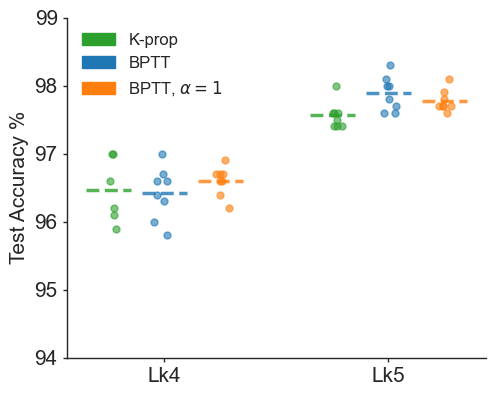

In [12]:
# KP vs BPTT vs BPTT-1
#[0, 42, 428, 781, 3407, 115, 256, 666]
KP_Lk4 = np.array([96.2, 95.9, 96.6, 97, 97., 96.1])
KP_Lk5 = np.array([97.6, 97.6, 97.6, 97.4, 97.4, 98, 97.5, 97.4])
BPTT_Lk4   = np.array([95.8, 96, 97, 96.3, 96.6, 96.6, 96.4, 96.7])
BPTT_Lk5   = np.array([98, 97.6, 97.6, 98.3, 97.8, 98.1, 98,  97.7]) #missing 256
BPTT_Lk4_1 = np.array([96.7, 96.6, 96.6, 96.4, 96.7, 96.7, 96.2, 96.9])
BPTT_Lk5_1 = np.array([98.1, 97.7, 97.7, 97.8, 97.6, 97.7, 97.7, 97.9])

Lk4 = [KP_Lk4, BPTT_Lk4, BPTT_Lk4_1]
Lk5 = [KP_Lk5, BPTT_Lk5, BPTT_Lk5_1]
colors = [green, blue, orange]

fig, ax = plt.subplots(1, figsize=(5, 4))

for i, d in enumerate(Lk4):
    x = np.random.normal(0.5+0.5*i, 0.04, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.6, s=25, color = colors[i])
    ax.hlines(d.mean(), xmin=0.3+0.5*i, xmax=0.7+0.5*i, linestyle='--', color = colors[i], alpha = 0.8, linewidth=2.5)

for i, d in enumerate(Lk5):
    x = np.random.normal(2.5+0.5*i, 0.04, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.6, s=25, color = colors[i])
    ax.hlines(d.mean(), xmin=2.3+0.5*i, xmax=2.7+0.5*i, linestyle='--', color = colors[i], alpha = 0.8, linewidth=2.5)

ax.set_ylabel("Test Accuracy %", fontsize=15)
#ax.set_xlabel("Models", fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([1, 3], ['Lk4', 'Lk5'])
#ax.set_yticks([95, 96, 97, 98])
ax.tick_params(axis='both', which='major', labelsize=15)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=green, label='K-prop'),
    plt.Rectangle((0, 0), 1, 1, color=blue, label='BPTT'),
    plt.Rectangle((0, 0), 1, 1, color=orange, label=r'BPTT, $\alpha=1$'),
]
# Legend inside plot box
ax.set_ylim(94, 99)
ax.legend(handles=handles, loc='best', frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/KPvsBPTT.png')
plt.show()

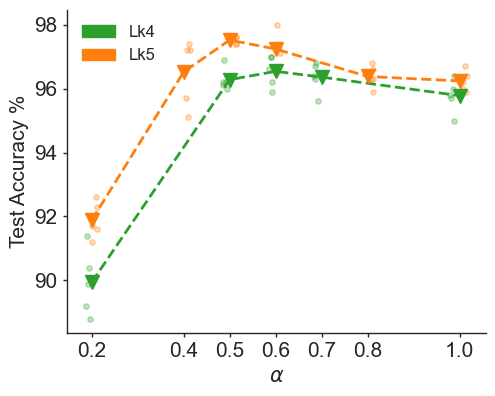

In [48]:
# rho scale
Lk4_alpha = [0.2, 0.5, 0.6, 0.7, 1.]
Lk5_alpha = [0.2, 0.4, 0.5, 0.6, 0.8, 1.]
Lk4_acc = np.array([
    [88.8, 91.4, 90.4, 89.2, 89.9], 
    [96, 96.9, 96.2, 96.2, 96.1], 
    [96.2, 95.9, 96.6, 97, 97], 
    [96.3, 95.6, 96.4, 96.8, 96.7], 
    [95, 96, 95.8, 96.4, 95.7]
])
Lk5_acc = np.array([
    [91.7, 91.2, 91.6, 92.3, 92.6], 
    [95.1, 97.2, 97.2, 95.7, 97.4], 
    [97.6, 97.6, 97.6, 97.4, 97.4], 
    [98, 97.3, 97.3, 96.5, 97.1], 
    [96.3, 96.8, 96.3, 95.9, 96.6],
    [96.4, 96, 96.2, 95.9, 96.7]
])

fig, ax = plt.subplots(1, figsize=(5, 4))

color4, color5 = green, orange
ax.plot(Lk4_alpha, Lk4_acc.mean(axis=1), marker='v', linestyle='--', color = color4, markersize=10, linewidth=2,)
ax.plot(Lk5_alpha, Lk5_acc.mean(axis=1), marker='v', linestyle='--', color = color5, markersize=10, linewidth=2,)

for i, d in enumerate(Lk4_acc):
    x = np.random.normal(Lk4_alpha[i]-0.01, 0.005, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.3, s=15, color = color4)

for i, d in enumerate(Lk5_acc):
    x = np.random.normal(Lk5_alpha[i]+0.01, 0.005, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.3, s=15, color = color5)

ax.set_ylabel("Test Accuracy %", fontsize=15)
ax.set_xlabel(r"$\alpha$", fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 1.], [0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 1.])
#ax.set_yticks([95, 96, 97, 98])
ax.tick_params(axis='both', which='major', labelsize=15)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color4, label='Lk4'),
    plt.Rectangle((0, 0), 1, 1, color=color5, label='Lk5'),
]
# Legend inside plot box
#ax.set_ylim(94, 99)
ax.legend(handles=handles, loc='best', frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/alphasweetpot.png')
plt.show()


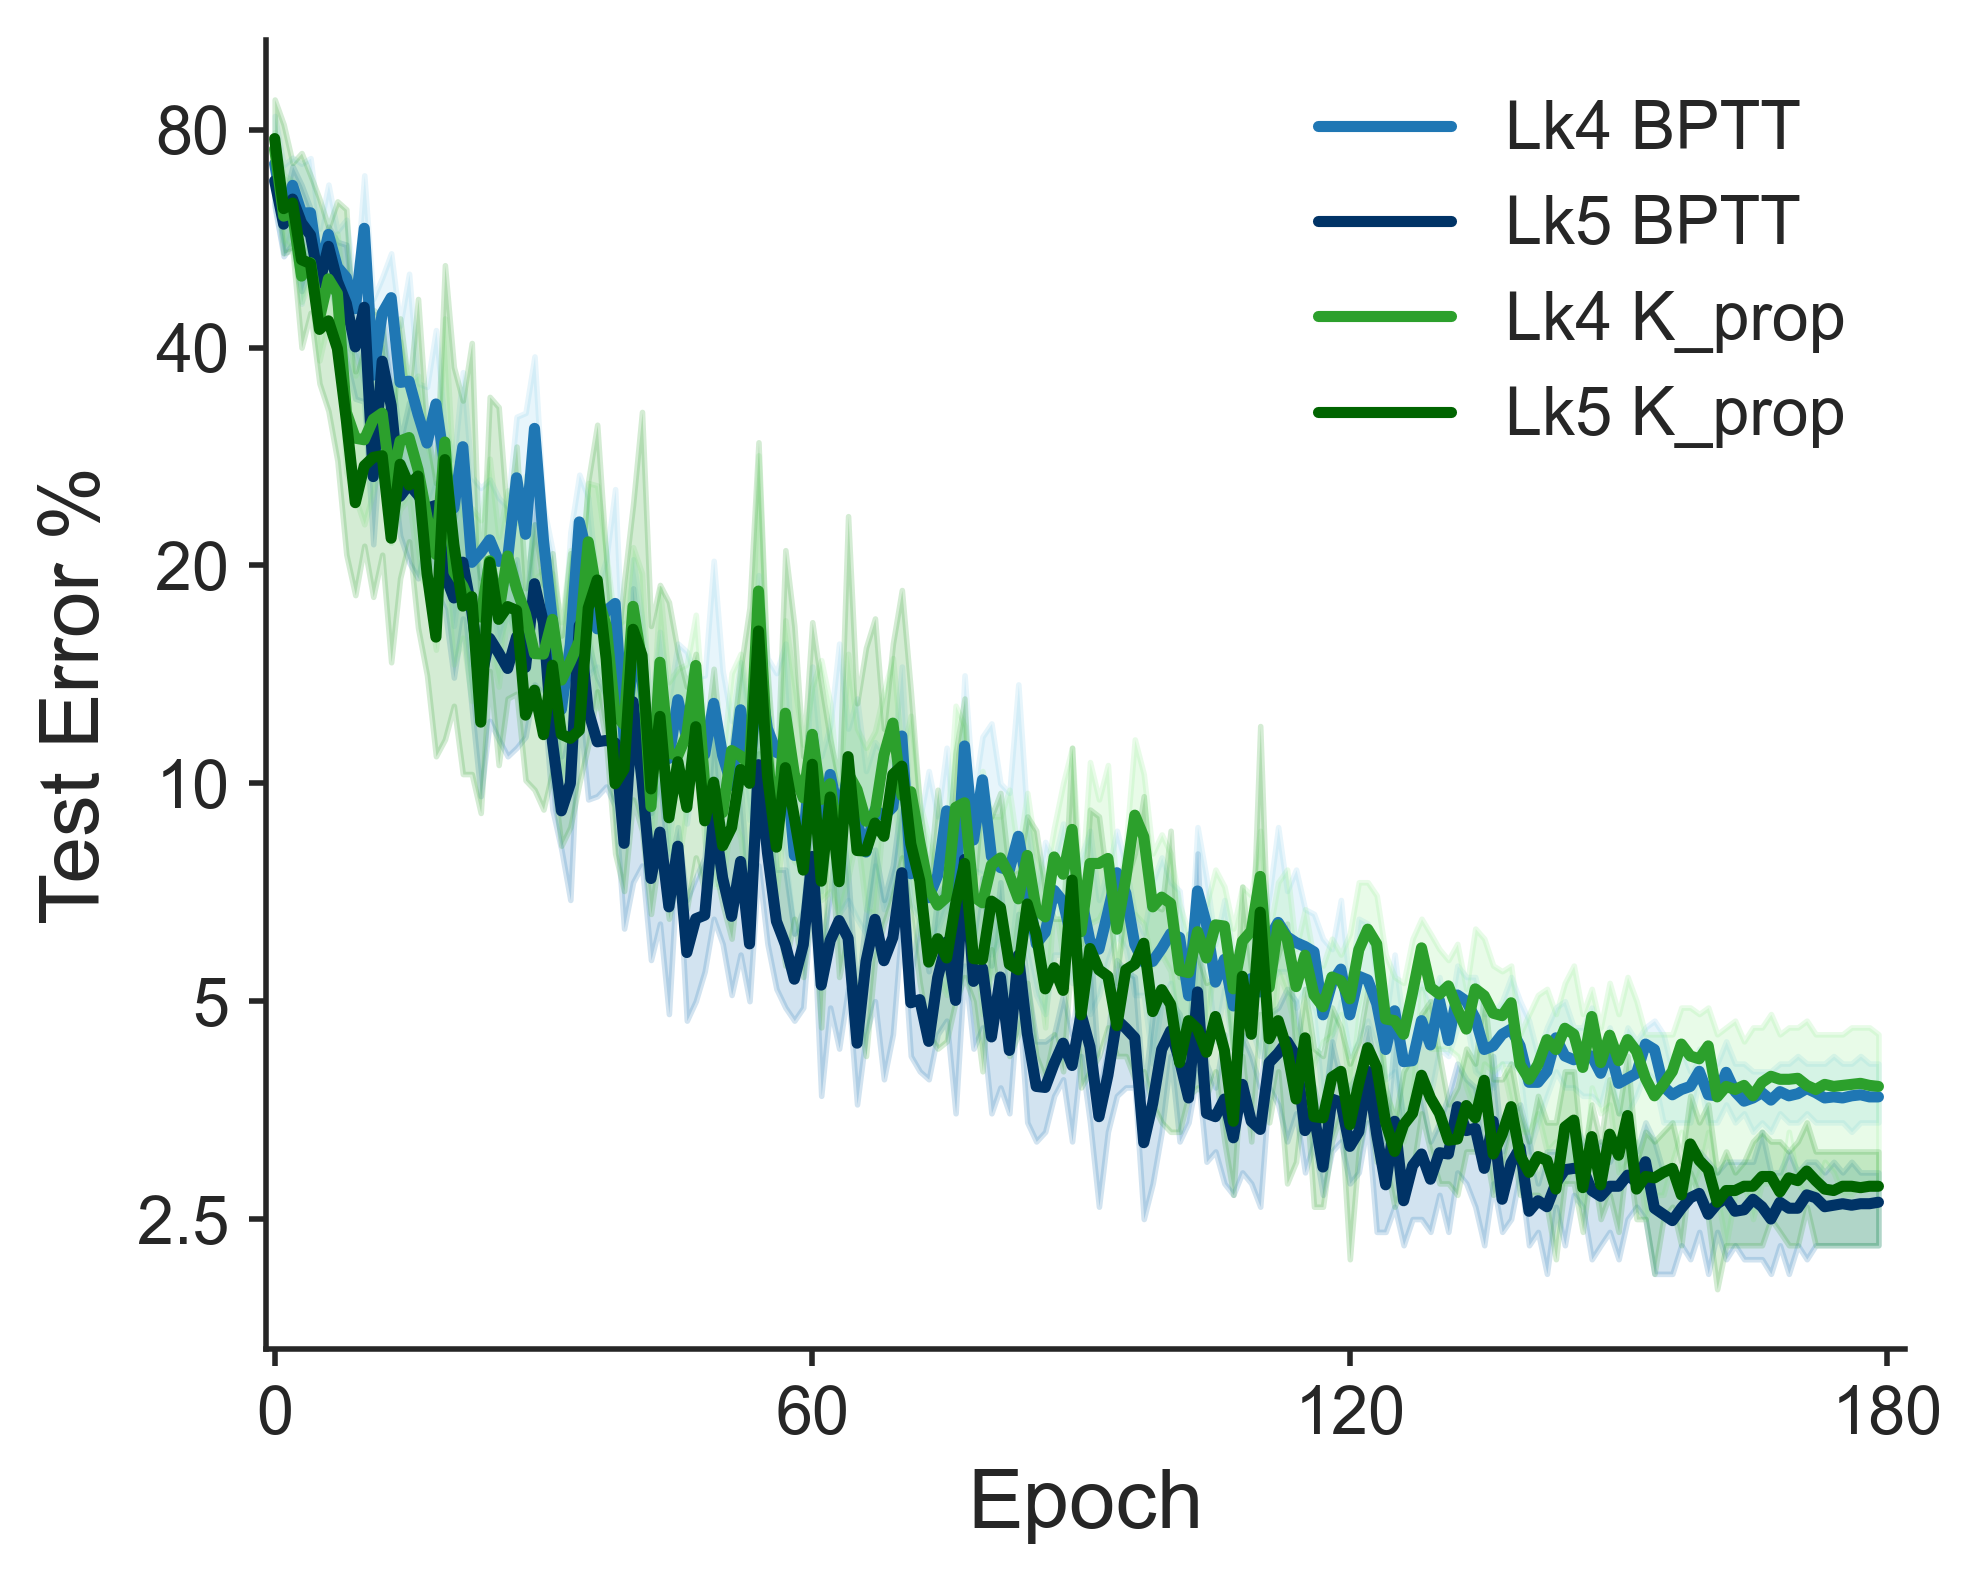

In [45]:
df = pd.read_csv("../Figures/L4L5.csv", index_col='Step')
epochs = np.arange(180)
### Large and Small model ###
fig, ax = plt.subplots(1, 1, figsize=(5, 4), sharey=True, dpi=400)



ax.plot(100-df["Group: SmallBPTT - test_acc"], label="Lk4 BPTT", color=blue, linewidth=2)
ax.fill_between(epochs, 100-df["Group: SmallBPTT - test_acc__MIN"], 100-df["Group: SmallBPTT - test_acc__MAX"], alpha=0.2, color=lightblue)
ax.plot(100-df["Group: L5BPTT - test_acc"], label="Lk5 BPTT", color=darkblue, linewidth=2)
ax.fill_between(epochs, 100-df["Group: L5BPTT - test_acc__MIN"], 100-df["Group: L5BPTT - test_acc__MAX"], alpha=0.2, color=blue)

ax.plot(100-df["Group: SmallV2 - test_acc"], label="Lk4 K_prop", color=green, linewidth=2)
ax.fill_between(epochs, 100-df["Group: SmallV2 - test_acc__MIN"], 100-df["Group: SmallV2 - test_acc__MAX"], alpha=0.2, color=lightgreen)
ax.plot(100-df["Group: L5V2 - test_acc"], label="Lk5 K_prop", color=darkgreen, linewidth=2)
ax.fill_between(epochs, 100-df["Group: L5V2 - test_acc__MIN"], 100-df["Group: L5V2 - test_acc__MAX"], alpha=0.2, color=green)

ax.set_xlim(-1, 182)
ax.set_yscale('log')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel('Epoch', fontsize = 15)
ax.set_ylabel('Test Error %', fontsize = 15)
ax.set_xticks([0, 60, 120, 180])
ax.set_yticks([2.5, 5, 10, 20, 40, 80], [2.5, 5, 10, 20, 40, 80])
ax.legend(loc='upper right', fontsize = 12)

plt.tight_layout()
plt.savefig('../Figures/MNIST1D_L4L5.png')
plt.show()

In [6]:
df = pd.read_csv("../Figures/L4L5.csv", index_col='Step')

In [7]:
df

,Group: SmallV2 - test_acc,Group: SmallV2 - test_acc__MIN,Group: SmallV2 - test_acc__MAX,Group: L5V2 - test_acc,Group: L5V2 - test_acc__MIN,Group: L5V2 - test_acc__MAX,Group: L5BPTT - test_acc,Group: L5BPTT - test_acc__MIN,Group: L5BPTT - test_acc__MAX,Group: SmallBPTT - test_acc,Group: SmallBPTT - test_acc__MIN,Group: SmallBPTT - test_acc__MAX
Step,,,,,,,,,,,,
0,24.7375,20.6,27.7,22.2000,11.9,30.1,31.9875,25.7,37.0,28.2000,16.4,37.5
1,39.2125,30.7,43.8,37.7500,18.6,46.0,40.7500,36.8,46.5,39.1250,28.5,45.9
2,38.7125,32.0,45.3,36.6250,28.0,45.4,35.8250,28.8,44.3,32.9625,26.8,41.5
3,49.7750,44.5,53.7,47.0875,25.7,60.0,40.5125,32.9,52.1,38.6250,28.2,54.0
4,47.6000,45.4,50.5,47.7375,30.8,55.3,42.7750,37.8,48.1,38.5625,26.9,43.2
...,...,...,...,...,...,...,...,...,...,...,...,...
175,96.1750,95.5,97.3,97.2250,96.9,97.7,97.3750,97.1,97.7,96.3250,95.9,96.6
176,96.1625,95.4,97.3,97.2250,96.9,97.7,97.3875,97.0,97.7,96.3000,95.9,96.7
177,96.1500,95.4,97.2,97.2375,96.9,97.7,97.3750,97.1,97.7,96.2875,95.8,96.6
